# Delta-Vega Deep Hedging

## Motivation

Classical delta hedging neutralizes a portfolio’s exposure to first-order movements in the underlying asset, but it leaves the portfolio exposed to changes in volatility—a source of risk that can be substantial under stochastic-volatility models such as Heston. One way to mitigate this residual vega exposure is to trade a second liquid option alongside the underlying, thereby constructing a delta-vega hedge. In practice, however, this problem becomes much harder to solve in closed form once realistic market frictions, such as transaction costs, are introduced. These frictions make the hedging problem path-dependent and destroy the clean analytic formulas available in the frictionless setting.

Deep hedging approaches this problem from a different angle: it formulates hedging as a sequential decision problem and trains a neural network to produce hedge positions directly from observed market states. This framework allows the objective function—here, an entropic risk measure—to incorporate transaction costs, discrete rebalancing, and other real-world constraints that classical Greek-based hedging methods do not naturally accommodate.

## Objectives

This notebook:

1. Simulates asset-price and variance paths under the Heston stochastic-volatility model, and prices both a target option (`C1`, an at-the-money call) and a vega-hedging instrument (`C2`, an out-of-the-money call) along each path using a semi-analytic Fourier pricer.
2. Trains recurrent neural-network hedgers (LSTM + MLP)—a **delta-only** hedger that trades only the underlying asset, and a **delta-vega** hedger that trades both the underlying and `C2`—under an entropic risk-measure loss across multiple transaction-cost regimes, including both cost-aware and cost-ignorant training variants, comparing indifference prices, tail-risk measures (VaR/CVaR), and full P&L distributions across models.
3. Examines the learned hedge-ratio trajectories along representative sample paths to better understand how the network adapts its hedging behavior to transaction costs and to the availability of a vega-hedging instrument.

The central goal is to quantify how much a learned delta-vega hedging strategy improves upon delta-only hedging in the presence of transaction costs.


## Setup

Imports and device selection. All simulation, pricing, and training below runs as batched tensor operations on GPU (CUDA, or MPS on Apple Silicon) — this is what makes it feasible to simulate and price millions of Heston paths and train multiple recurrent hedgers in this notebook.

In [3]:
# Imports
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Using device: ', device)

Using device:  cuda


## The Heston Model & Experiment Configuration

### The Heston model

The Heston (1993) model is the standard stochastic-volatility extension of Black-Scholes. In this notebook, both path simulation and option pricing are carried out under the real-world measure. This choice is deliberate: once proportional transaction costs are introduced, the hedging problem becomes incomplete, so there is no unique arbitrage-free replication price tied to a single risk-neutral measure. The relevant object is instead the hedger’s utility- or risk-based indifference price under the physical dynamics of the model. Under this measure, the state variables evolve as

$$dS_t = r S_t \, dt + \sqrt{v_t},S_t \, dW_t^S$$
$$dv_t = \kappa(\theta - v_t) \, dt + \xi \sqrt{v_t} \, dW_t^v$$
$$d\langle W^S, W^v\rangle_t = \rho \, dt$$

- $S_t$ is the underlying asset price at time $t$
- $v_t$ is the instantaneous variance, following a mean-reverting square-root (CIR) process
- $\theta$ (THETA) is the long-run average variance
- $\kappa$ (KAPPA) is the speed of mean reversion of variance toward $\theta$
- $\xi$ (XI) is the volatility of volatility
- $\rho$ (RHO) is the instantaneous correlation between the Brownian motions $W_t^S$ and $W_t^v$
- $r$ (R) is the risk-free rate of return.

### Experiment configuration

The cell below sets:
- **Heston parameters** for the simulated market.
- **Contract parameters**: `C1` (strike `K1`, ATM, maturity `T1` = 22 trading days) is the option being hedged; `C2` (strike `K2`, OTM, maturity `T2` = 43 trading days) is the auxiliary instrument used for vega hedging. Hedging occurs daily over `N` = 21 steps with liquidation on the final day.
- **Simulation sizes** for the five data splits used throughout (train / val / price / test / plot — see the Data Generation section below).
- **Training hyperparameters** for the entropic-risk objective and optimizer, shared across all models trained in this notebook.

In [4]:
# Heston model parameters
S0 = 100.00           # initial stock price
v0 = 0.04             # initial variance (initial volatility = 20%)
KAPPA = 1.0           # mean reversion speed
THETA = 0.09          # long-run variance
XI = 0.40             # volatility of volatility
RHO = -0.7            # correlation between stock and variance Brownian

# Contract parameters
K1 = 100.0            # strike of the hedged call (ATM)
K2 = 110.0            # strike of the vega hedge call (OTM)
T1 = 22               # maturity of the hedged call in trading days
T2 = 43               # maturity of the vega hedge call in trading days
N = 21                # number of hedging steps (hedge on days 0-20)
DT = 1/252            # one trading day in years
R = 0.00              # risk-free rate of return

# Simulation sizes
N_TRAIN = 1_000_000   # num of training paths
N_VAL = 100_000       # num of validation paths used in training
N_PRICE = 100_000     # num of paths used for computing indifference prices
N_TEST = 100_000      # num of test paths used for computing net P&L
N_PLOT = 5            # num of paths used for plotting
SEED = 41

# Training hyperparameters
LAMBDA = 0.5          # entropic risk measure coefficient
LR = 1e-4             # learning rate
N_EPOCHS = 500        # number of epochs used during training
BATCH = 10_000        # batch size used during training
MLP_HIDDEN = 64       # number of neurons in each hidden layer of the MLP
LSTM_HIDDEN = 32      # size of h_t and c_t in the LSTM
MAX_GRAD_NORM = 1.0

# Save path — mounts Drive on Colab; falls back to a local cache otherwise
try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_PATH = '/content/drive/MyDrive/deep_hedging_delta_vega/'
except ImportError:
    SAVE_PATH = './data/'
os.makedirs(SAVE_PATH, exist_ok=True)


Mounted at /content/drive


## Simulation & Pricing Engine

To simulate the Heston market, we use two pieces of infastructure:

1. **Path simulation** (`simulate_heston_paths`): an Euler-Maruyama discretization of the Heston SDEs above, using correlated Gaussian increments ($Z_S = \rho Z_V + \sqrt{1-\rho^2} Z_\perp$) and a full-truncation scheme (`v_pos = clamp(v, min=0)`) to keep the variance process numerically well-behaved when it dips near zero.
2. **Option pricing along paths** (`price_option_along_path` / `heston_call_price`, below): rather than pricing by nested Monte Carlo — which would be prohibitively expensive when we need a price at every one of 22 timesteps along ~1M paths — European call prices are computed via the semi-analytic Heston formula, evaluated by Gauss-Legendre quadrature over the model's characteristic function. This is exact up to quadrature error and cheap enough to batch entirely on GPU.

Together these produce, for every simulated path, the full time series of the stock price, variance, and both option prices (`C1`, `C2`) needed to compute hedging P&L later.

In [5]:
# Write functions that simulate Heston paths and price options along those paths using PyTorch on GPU.

def simulate_heston_paths(n_paths, S0, v0, kappa, theta, xi, rho, r, N, DT, seed=None):
    """
    Simulates Heston (S_t, v_t) paths using PyTorch on GPU.
    Returns S, V each of shape (n_paths, N+1) as torch tensors on device.
    """
    if seed is not None:
        torch.manual_seed(seed)

    Z1 = torch.randn(n_paths, N, device=device)
    Z2 = torch.randn(n_paths, N, device=device)
    ZV = Z1
    ZS = rho * Z1 + torch.sqrt(torch.tensor(1 - rho**2, device=device)) * Z2

    S = torch.zeros(n_paths, N + 1, device=device)
    V = torch.zeros(n_paths, N + 1, device=device)

    S[:, 0] = S0
    V[:, 0] = v0

    for t in range(N):
        v_pos    = torch.clamp(V[:, t], min=0.0)
        sv       = torch.sqrt(v_pos * DT)
        S[:, t+1] = S[:, t] * torch.exp((r - 0.5 * v_pos) * DT + sv * ZS[:, t])
        V[:, t+1] = V[:, t] + kappa * (theta - V[:, t]) * DT + xi * sv * ZV[:, t]

    return S, V


def price_option_along_path(S, V, K, T_days, N, DT, r, pricer):
    """
    Price a European call with strike K and maturity T_days
    at each node along pre-simulated paths of (S_t, v_t)
    Returns C of shape (n_paths, N+1) as a torch tensor on device.
    """
    n_paths = S.shape[0]
    C = torch.zeros(n_paths, N + 1, device=device)

    for t in range(N + 1):
        tau   = (T_days - t) * DT
        v_pos = torch.clamp(V[:, t], min=0.0)

        if tau <= 0:
            C[:, t] = torch.clamp(S[:, t] - K, min=0.0)
        else:
            C[:, t] = pricer(S[:, t], v_pos, tau, K, r)

    return C


def simulate_heston(n_paths, pricer, seed=None):
    """
    Simulate Heston paths and price both options along each path.
    Returns S, V, C1, C2 each of shape (n_paths, N+1) as torch tensors on device.
    """
    S, V = simulate_heston_paths(
        n_paths, S0, v0, KAPPA, THETA, XI, RHO, R, N, DT, seed=seed
    )
    C1 = price_option_along_path(S, V, K1, T1, N, DT, R, pricer)
    C2 = price_option_along_path(S, V, K2, T2, N, DT, R, pricer)

    return S, V, C1, C2

In [6]:
# Heston Call Options Pricer — runs entirely on GPU

# Pre-compute Gauss-Legendre nodes and weights on device
_phi_nodes, _weights = np.polynomial.legendre.leggauss(64)
_a_lim, _b_lim   = 1e-8, 500.0
_phi_mapped       = 0.5 * (_b_lim - _a_lim) * _phi_nodes + 0.5 * (_b_lim + _a_lim)
_weights_mapped   = 0.5 * (_b_lim - _a_lim) * _weights
_phi_gl     = torch.tensor(_phi_mapped,     dtype=torch.complex64, device=device)
_weights_gl = torch.tensor(_weights_mapped, dtype=torch.complex64, device=device)


def heston_call_price(S, v, tau, K, r, kappa=KAPPA, theta=THETA, xi=XI, rho=RHO):
    """
    Heston semi-analytic European call price via Gauss-Legendre quadrature.

    Parameters
    ----------
    S   : tensor (n_paths,) -- current stock prices
    v   : tensor (n_paths,) -- current variances (must be >= 0)
    tau : float             -- time to maturity in years
    K   : float             -- strike price
    r   : float             -- risk-free rate

    Returns
    -------
    prices : tensor (n_paths,) on device
    """
    dev = S.device
    x   = torch.log(S).to(torch.complex64).unsqueeze(1)   # (n_paths, 1)
    v   = v.to(torch.complex64).unsqueeze(1)               # (n_paths, 1)
    phi = _phi_gl.unsqueeze(0)                             # (1, n_points)
    a   = kappa * theta

    def char_func(j):
        u_val = 0.5 if j == 1 else -0.5
        b_val = (kappa - rho * xi) if j == 1 else kappa

        b_   = torch.tensor(b_val, dtype=torch.complex64, device=dev)
        u_   = torch.tensor(u_val, dtype=torch.complex64, device=dev)
        a_   = torch.tensor(a,     dtype=torch.complex64, device=dev)
        xi_  = torch.tensor(xi,    dtype=torch.complex64, device=dev)
        rho_ = torch.tensor(rho,   dtype=torch.complex64, device=dev)
        r_   = torch.tensor(r,     dtype=torch.complex64, device=dev)
        tau_ = torch.tensor(tau,   dtype=torch.complex64, device=dev)
        i    = torch.tensor(1j,    dtype=torch.complex64, device=dev)

        d = torch.sqrt((rho_ * xi_ * i * phi - b_)**2
                       - xi_**2 * (2 * u_ * i * phi - phi**2))
        g = (b_ - rho_ * xi_ * i * phi + d) / (b_ - rho_ * xi_ * i * phi - d)
        C = (r_ * i * phi * tau_
             + (a_ / xi_**2) * ((b_ - rho_ * xi_ * i * phi + d) * tau_
                                 - 2 * torch.log((1 - g * torch.exp(d * tau_)) / (1 - g))))
        D = ((b_ - rho_ * xi_ * i * phi + d) / xi_**2
             * (1 - torch.exp(d * tau_)) / (1 - g * torch.exp(d * tau_)))
        return torch.exp(C + D * v + i * phi * x)

    def integrand(j):
        i  = torch.tensor(1j, dtype=torch.complex64, device=dev)
        K_ = torch.tensor(K,  dtype=torch.complex64, device=dev)
        return (torch.exp(-i * phi * torch.log(K_)) * char_func(j) / (i * phi)).real

    I1 = integrand(1) @ _weights_gl.real
    I2 = integrand(2) @ _weights_gl.real

    P1 = 0.5 + I1 / torch.pi
    P2 = 0.5 + I2 / torch.pi

    return S * P1 - K * np.exp(-r * tau) * P2

## Data Generation

Five path splits are simulated (or loaded from cache if already computed), each with an independent random seed:

- **`train`** (1,000,000 paths) — used to fit the networks' weights.
- **`val`** (100,000 paths) — held out during training for early stopping and checkpoint selection.
- **`price`** (100,000 paths) — used only once, after training, to compute each model's entropic indifference premium.
- **`test`** (100,000 paths) — a further independent sample used to evaluate premium-adjusted P&L and risk statistics.
- **`plot`** (5 paths) — a handful of paths kept aside purely for visualizing individual hedge trajectories later.

Keeping `price` and `test` separate matters: if the same sample were used both to set a model's premium and to report its P&L statistics, the reported risk metrics would be biased by having been implicitly fit to that sample. All splits are cached to disk so re-running the notebook doesn't require re-simulating.

In [7]:
# Simulate the paths to be used for training, validating, pricing, and testing.
# Skip simulation if data already exists on Drive.

if all(os.path.exists(SAVE_PATH + name + '.pt') for name in [
    'S_train', 'V_train', 'C1_train', 'C2_train',
    'S_val',   'V_val',   'C1_val',   'C2_val',
    'S_price', 'V_price', 'C1_price', 'C2_price',
    'S_test',  'V_test',  'C1_test',  'C2_test',
    'S_plot',  'V_plot',  'C1_plot',  'C2_plot',
]):
    print('Data found on Drive — skipping simulation. Run the load cell below.')
else:
    S_train, V_train, C1_train, C2_train = simulate_heston(N_TRAIN, heston_call_price, seed=5)
    S_val,   V_val,   C1_val,   C2_val   = simulate_heston(N_VAL,   heston_call_price, seed=6)
    S_price, V_price, C1_price, C2_price = simulate_heston(N_PRICE, heston_call_price, seed=7)
    S_test,  V_test,  C1_test,  C2_test  = simulate_heston(N_TEST,  heston_call_price, seed=8)
    S_plot,  V_plot,  C1_plot,  C2_plot  = simulate_heston(N_PLOT,  heston_call_price, seed=9)

    os.makedirs(SAVE_PATH, exist_ok=True)

    for name, tensor in [
        ('S_train',  S_train),  ('V_train',  V_train),  ('C1_train', C1_train), ('C2_train', C2_train),
        ('S_val',    S_val),    ('V_val',    V_val),    ('C1_val',   C1_val),   ('C2_val',   C2_val),
        ('S_price',  S_price),  ('V_price',  V_price),  ('C1_price', C1_price), ('C2_price', C2_price),
        ('S_test',   S_test),   ('V_test',   V_test),   ('C1_test',  C1_test),  ('C2_test',  C2_test),
        ('S_plot',   S_plot),   ('V_plot',   V_plot),   ('C1_plot',  C1_plot),  ('C2_plot',  C2_plot),
    ]:
        torch.save(tensor.cpu(), SAVE_PATH + name + '.pt')

    print(f'All splits saved to {SAVE_PATH}')

Data found on Drive — skipping simulation. Run the load cell below.


In [8]:
# Load pre-simulated data splits from Drive

for name in [
    'S_train', 'V_train', 'C1_train', 'C2_train',
    'S_val',   'V_val',   'C1_val',   'C2_val',
    'S_price', 'V_price', 'C1_price', 'C2_price',
    'S_test',  'V_test',  'C1_test',  'C2_test',
    'S_plot',  'V_plot',  'C1_plot',  'C2_plot',
]:
    globals()[name] = torch.load(SAVE_PATH + name + '.pt', map_location=device, weights_only=True)

print('All splits loaded from', SAVE_PATH)

All splits loaded from /content/drive/MyDrive/deep_hedging_delta_vega/


## Model Architectures

Both hedgers share the same backbone: an **LSTM followed by an MLP head**, applied recurrently at each of the `N` daily hedging dates.

**Why use an LSTM? Inferring latent volatility from price history.** In the Heston model, the variance process $v_t$ is latent: it is not directly observed, traded, or quoted. A real hedger therefore does not have access to $v_t$ itself, but only to observable market information such as the realized return path and option prices, which implicitly reflect the market’s assessment of volatility. The role of the LSTM is to address this inference problem. At each step, it processes the sequence of log-returns $\log(S_t/S_{t-1})$ and updates a hidden state $h_t$, which serves as a learned summary of the recent price history and, in effect, a proxy for the current volatility regime.

This mirrors how a trader infers that volatility has increased from recent market behavior rather than from directly observing the variance process. The hidden state is then passed to the MLP together with directly observable features—time, moneyness, previous hedge positions, and option prices—so that the network can condition its hedge decisions on an internal estimate of latent variance without imposing a hand-crafted volatility filter. By contrast, a purely feedforward architecture would have no memory of the return path and therefore no mechanism for inferring whether volatility is currently elevated or subdued.

**`DeltaHedger`** outputs a single hedge ratio, $\delta_S$, for the underlying asset $S$ at each step. This serves as the delta-only baseline architecture.

**`DeltaVegaHedger`** uses the same backbone but outputs a two-dimensional hedge vector $(\delta_S, \delta_{C_2})$ at each step, allowing the network to trade both the underlying and the out-of-the-money call `C2` in order to offset vega risk.

In both models, the MLP head maps the feature tuple

$$\bigl(t,\ \log(S_t/K_1),\ \text{previous hedge ratio(s)},\ h_t,\ \text{option price(s)}\bigr)$$

to the next hedge ratio(s). Including the previous hedge position as an input allows the network to learn the trade-off between hedge accuracy and turnover, and therefore to internalize the effect of transaction costs.

In [9]:
# Define the DeltaHedger, which delta hedges only
class DeltaHedger(nn.Module):
    def __init__(self, name=None, c_s=0.0, c_s_eval=0.0, premium=0,
                 lstm_hidden=LSTM_HIDDEN, mlp_hidden=MLP_HIDDEN):
        super().__init__()
        self.name        = name
        self.c_s         = c_s
        self.c_call      = 0.0        # never trade C2
        self.c_s_eval    = c_s_eval
        self.c_call_eval = 0.0
        self.premium     = premium

        self.h0   = nn.Parameter(torch.zeros(1, 1, lstm_hidden))
        self.c0   = nn.Parameter(torch.zeros(1, 1, lstm_hidden))
        self.lstm = nn.LSTM(input_size=1, hidden_size=lstm_hidden, batch_first=True)

        # Input: (t, moneyness, delta_S_prev, h_t, C1_t)  →  4 + lstm_hidden
        self.mlp = nn.Sequential(
            nn.Linear(4 + lstm_hidden, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, mlp_hidden),       nn.ReLU(),
            nn.Linear(mlp_hidden, 1)
        )

    def forward(self, S, C1, C2):          # C2 accepted but ignored
        n_paths = S.shape[0]
        dev     = S.device

        h = self.h0.expand(-1, n_paths, -1).contiguous()
        c = self.c0.expand(-1, n_paths, -1).contiguous()

        log_rets = torch.cat([
            torch.zeros(n_paths, 1, 1, device=dev),
            torch.log(S[:, 1:N] / S[:, :N-1]).unsqueeze(-1),
        ], dim=1)
        h_all, _ = self.lstm(log_rets, (h, c))

        moneyness = torch.log(S[:, :N] / K1)
        c1_feat   = C1[:, :N]

        delta_prev = torch.zeros(n_paths, 1, device=dev)
        deltas     = []

        for t in range(N):
            t_feat    = torch.full((n_paths, 1), t / N, device=dev)
            mlp_input = torch.cat([
                t_feat,
                moneyness[:, t:t+1],
                delta_prev,
                h_all[:, t, :],
                c1_feat[:, t:t+1],
            ], dim=1)
            delta_s    = self.mlp(mlp_input)                          # (n_paths, 1)
            delta_full = torch.cat(
                [delta_s, torch.zeros(n_paths, 1, device=dev)], dim=1
            )                                                         # (n_paths, 2)
            deltas.append(delta_full)
            delta_prev = delta_s

        return torch.stack(deltas, dim=1)                             # (n_paths, N, 2)


In [10]:
# Define the DeltaVegaHedger, which delta and vega hedges
class DeltaVegaHedger(nn.Module):
    def __init__(self, name = None, c_s = 0.0, c_call = 0.0, c_s_eval = 0.0, c_call_eval = 0.0, premium = 0, lstm_hidden=LSTM_HIDDEN, mlp_hidden=MLP_HIDDEN):
        super().__init__()
        # Model name (used for saving/loading)
        self.name = name

        # Transaction cost coefficients for training
        self.c_s    = c_s
        self.c_call = c_call

        # Transaction cost coefficients for evaluation
        self.c_s_eval    = c_s_eval
        self.c_call_eval = c_call_eval

        # Premium for the hedged call (used in indifference pricing)
        self.premium = premium

        # Learned initial hidden and cell states
        self.h0   = nn.Parameter(torch.zeros(1, 1, lstm_hidden))
        self.c0   = nn.Parameter(torch.zeros(1, 1, lstm_hidden))

        # LSTM: encodes log-return history into a latent volatility state h_t
        # Processes the full N-step sequence in one GPU call
        self.lstm = nn.LSTM(input_size=1, hidden_size=lstm_hidden, batch_first=True)

        # MLP head: (t, log(S_t/K1), delta_{t-1}, h_t, C1_t, C2_t) -> delta_t
        self.mlp = nn.Sequential(
            nn.Linear(6 + lstm_hidden, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, mlp_hidden),       nn.ReLU(),
            nn.Linear(mlp_hidden, 2)
        )

    def forward(self, S, C1, C2):
        n_paths = S.shape[0]
        dev     = S.device

        h = self.h0.expand(-1, n_paths, -1).contiguous()  # (1, n_paths, lstm_hidden)
        c = self.c0.expand(-1, n_paths, -1).contiguous()

        # Build the full log-return sequence in one vectorised op:
        # step 0 -> 0  (no prior return),  step t -> log(S_t / S_{t-1})
        log_rets = torch.cat([
            torch.zeros(n_paths, 1, 1, device=dev),
            torch.log(S[:, 1:N] / S[:, :N-1]).unsqueeze(-1),
        ], dim=1)                                          # (n_paths, N, 1)

        # Single LSTM call over the full sequence — one GPU kernel instead of N
        h_all, _ = self.lstm(log_rets, (h, c))            # (n_paths, N, lstm_hidden)

        # Precompute market features for all steps outside the loop
        moneyness = torch.log(S[:, :N] / K1)              # (n_paths, N)
        c1_feat   = C1[:, :N]                             # (n_paths, N)
        c2_feat   = C2[:, :N]                             # (n_paths, N)

        # MLP loop — must remain sequential: delta_{t-1} is an input at step t
        delta_prev = torch.zeros(n_paths, 2, device=dev)
        deltas     = []

        for t in range(N):
            t_feat    = torch.full((n_paths, 1), t / N, device=dev)
            mlp_input = torch.cat([
                t_feat,
                moneyness[:, t:t+1],
                delta_prev,
                h_all[:, t, :],
                c1_feat[:, t:t+1],
                c2_feat[:, t:t+1],
            ], dim=1)
            delta_t    = self.mlp(mlp_input)
            deltas.append(delta_t)
            delta_prev = delta_t

        return torch.stack(deltas, dim=1)                 # (n_paths, N, 2)

## Training Objective: P&L and Entropic Risk

compute_pnl constructs the terminal profit-and-loss for each simulated path given a sequence of hedge ratios. For a short position in the target option, terminal P&L consists of cumulative gains and losses from trading the underlying asset $S$ and the hedging option $C_2$, minus proportional transaction costs incurred at each rebalance, and minus the option payoff owed at maturity. Concretely,


$$
\mathrm{pnl} = \underbrace{\sum_{t=0}^{N-1} \left(\delta_S^t (S_{t+1} - S_t) + \delta_{C_2}^t (C_2^{t+1} - C_2^t)\right)}_{\text{hedging gains}}
\;-\; \underbrace{\sum_{t=0}^{N-1} \left(c_s \left|\delta_S^t - \delta_S^{t-1}\right| S_t + c_{\mathrm{call}} \left|\delta_{C_2}^t - \delta_{C_2}^{t-1}\right| C_2^t\right)}_{\text{transaction costs}}
\;-\; \underbrace{\max(S_N - K_1,\, 0)}_{\text{option payoff}},
$$
with initial hedge positions $\delta_S^{-1}=\delta_{C_2}^{-1}=0$. Here c_s and c_call denote the proportional transaction-cost rates for trading the stock and the hedging option, respectively.


**`entropic_loss`** defines the training objective via the entropic risk measure
$$
\mathrm{ERM}_\lambda(\mathrm{pnl})
= \frac{1}{\lambda}\log \mathbb{E}\left[e^{-\lambda \cdot \mathrm{pnl}}\right].
$$

This is the standard objective in the deep-hedging literature (e.g. Buehler et al., 2019) for two main reasons. First, it is a convex, risk-averse objective: it penalizes adverse tail outcomes much more strongly than a mean or mean-squared-error criterion, which is important in hedging problems where the primary concern is not average performance but exposure to rare, severe losses. Second, minimizing the entropic risk over admissible hedging strategies naturally yields an indifference price. At the optimum, the value of $\mathrm{ERM}_\lambda$ can be interpreted as the premium at which the hedger is indifferent between selling and hedging the option and not entering the position at all. This indifference premium is computed explicitly later in the Results section.

$$
\textbf{In this notebook all models are trained using the entropic risk measure with } \lambda = 0.5.
$$

In [11]:
# Define the net P&L function
def compute_pnl(deltas, S, C2, c_s, c_call):
  """
  Compute the P&L for each path
  Parameters
    ----------
    deltas : tensor (n_paths, N, 2)  -- hedge ratios for days 0–20
    S      : tensor (n_paths, N+1)   -- stock prices, days 0–21
    C2     : tensor (n_paths, N+1)   -- vega hedge call prices, days 0–21
    c_s    : float                   -- proportional transaction cost for S
    c_call : float                   -- proportional transaction cost for C2

  Returns
  -------
  pnl : tensor (n_paths,)
  """
  # Infer number of paths from S
  n_paths = S.shape[0]

  # Unpack hedge ratios
  delta_s = deltas[:, :, 0]     # (n_paths, N) -- delta for underlying
  delta_c = deltas[:, :,1]   # (n_paths, N) -- delta for vega hedge

  # Hedging gains
  dS = S[:, 1:] - S[:, :-1]     # (n_paths, N) -- stock price increments
  dC2 = C2[:, 1:] - C2[:, :-1]  # (n_paths, N) -- vega hedge price increments

  hedging_gains = (delta_s * dS + delta_c * dC2).sum(dim=1)   # (n_paths,)

  # Transaction costs
  # Trade size is the change in position: delta_t - delta_{t-1}
  # Here delta_{-1} = 0
  zero = torch.zeros(n_paths, 1, device=S.device)

  delta_s_prev = torch.cat([zero, delta_s[:, :-1]], dim=1)   # (n_paths, N)
  delta_c_prev = torch.cat([zero, delta_c[:, :-1]], dim=1)   # (n_paths, N)

  trade_s = torch.abs(delta_s - delta_s_prev)                # (n_paths, N)
  trade_c = torch.abs(delta_c - delta_c_prev)                # (n_paths, N)

  tc = (c_s * trade_s * S[:, :-1] + c_call * trade_c * C2[:, :-1]).sum(dim=1)  # (n_paths,)

  # Terminal liability
  liability = torch.clamp(S[:, -1] - K1, min=0.0)            # (n_paths,)

  return hedging_gains - tc - liability

In [12]:
# Define the entropic risk measure to be used as loss function during training
def entropic_loss(pnl, lam):
    """
    Entropic risk measure loss.
    ERM = (1/lam) * log(E[exp(-lam * pnl)])

    Parameters
    ----------
    pnl : tensor (n_paths,) -- P&L for each path
    lam : float             -- risk aversion parameter

    Returns
    -------
    loss : scalar tensor
    """
    return (1 / lam) * torch.logsumexp(-lam * pnl - torch.log(torch.tensor(pnl.shape[0], dtype=torch.float32, device=pnl.device)), dim=0)

## Training Loop

`train_model` is a generic training routine used for every hedger and every transaction-cost configuration considered below. It performs mini-batch optimization with Adam over shuffled training paths, applies gradient-norm clipping for stability, tracks validation loss every 10 epochs, saves the best-performing checkpoint, and uses early stopping when the validation loss plateaus. Centralizing this logic in a single shared function ensures that all models are trained under identical optimization settings. This makes the subsequent comparisons across hedgers and cost regimes consistent and fair.


In [13]:
def train_model(model,
                S_train, C1_train, C2_train,
                S_val,   C1_val,   C2_val,
                loss_fn, lr=LR, n_epochs=N_EPOCHS, batch_size=BATCH,
                patience=5, model_name='model', max_grad_norm=MAX_GRAD_NORM):
    """
    Train the model using the provided training and validation data.

    Parameters
    ----------
    model      : DeltaHedger or DeltaVegaHedger
    S_train    : tensor (N_TRAIN, N+1)
    C1_train   : tensor (N_TRAIN, N+1)
    C2_train   : tensor (N_TRAIN, N+1)
    S_val      : tensor (N_VAL, N+1)
    C1_val     : tensor (N_VAL, N+1)
    C2_val     : tensor (N_VAL, N+1)
    loss_fn    : callable(pnl) -> scalar
    lr         : float -- learning rate
    n_epochs   : int
    batch_size : int
    patience   : int -- early stopping patience (in units of 10 epochs)

    Returns
    -------
    val_losses : list of (epoch, val_loss) recorded every 10 epochs
    """

    # Define intended cost coefficients for the model (used in compute_pnl)
    c_s    = model.c_s
    c_call = model.c_call

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n_train   = S_train.shape[0]

    # Move all data to GPU once — eliminates per-batch CPU→GPU transfers
    S_tr  = S_train.to(device);  C1_tr = C1_train.to(device);  C2_tr = C2_train.to(device)
    S_vl  = S_val.to(device);    C1_vl = C1_val.to(device);    C2_vl = C2_val.to(device)

    val_losses        = []
    best_val_loss     = float('inf')
    epochs_no_improve = 0

    for epoch in tqdm(range(1, n_epochs + 1)):

        # Training
        model.train()

        # Shuffle index on GPU — no CPU round-trip needed on CUDA
        perm    = torch.randperm(n_train, device=device)
        S_shuf  = S_tr[perm]
        C1_shuf = C1_tr[perm]
        C2_shuf = C2_tr[perm]

        epoch_loss = 0.0
        n_batches  = 0

        for start in range(0, n_train, batch_size):
            sl   = slice(start, start + batch_size)
            S_b  = S_shuf[sl];  C1_b = C1_shuf[sl];  C2_b = C2_shuf[sl]

            optimizer.zero_grad(set_to_none=True)
            deltas = model(S_b, C1_b, C2_b)
            pnl    = compute_pnl(deltas, S_b, C2_b, c_s, c_call)
            loss   = loss_fn(pnl)
            loss.backward()
            if max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches  += 1

        # Validation every 10 epochs
        if epoch % 10 == 0:
            model.eval()
            with torch.no_grad():
                pnl_chunks = []
                for vstart in range(0, S_vl.shape[0], batch_size):
                    vsl   = slice(vstart, vstart + batch_size)
                    S_vb  = S_vl[vsl];  C1_vb = C1_vl[vsl];  C2_vb = C2_vl[vsl]
                    d_vb  = model(S_vb, C1_vb, C2_vb)
                    pnl_chunks.append(compute_pnl(d_vb, S_vb, C2_vb, c_s, c_call))
                pnl_val  = torch.cat(pnl_chunks)
                val_loss = loss_fn(pnl_val).item()

            val_losses.append((epoch, val_loss))
            tqdm.write(f'Epoch {epoch:4d} | Train loss: {epoch_loss/n_batches:.4f} | Val loss: {val_loss:.4f}')

            if val_loss < best_val_loss:
                best_val_loss     = val_loss
                epochs_no_improve = 0
                torch.save(model.state_dict(), SAVE_PATH + f'{model_name}_best.pt')
                tqdm.write(f'  -> checkpoint saved ({model_name}_best.pt)')
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    tqdm.write(f'Early stopping at epoch {epoch}.')
                    break

    return val_losses

In [14]:
# Define a function that plots the validation losses across epochs for training multiple models on the same graph
def plot_val_losses(val_losses_dict):
    plt.figure(figsize=(10, 5))
    for name, val_losses in val_losses_dict.items():
        epochs = [e for e, _ in val_losses]
        losses = [l for _, l in val_losses]
        plt.plot(epochs, losses, lw=1.5, marker='o', markersize=3, label=name)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.title('Validation Loss vs Epoch')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Experiment Grid: Cost-Aware vs. Cost-Ignorant Training

This section addresses the notebook’s central experimental question: **does it improve hedging performance to account for transaction costs during training, or is it sufficient to train as though trading were frictionless and simply absorb the costs at evaluation time?**

For both the delta-only and delta-vega architectures, and for each transaction-cost regime, we train two variants:

* **Cost-aware**: the training loss incorporates the true transaction costs (`c_s`, `c_call` > 0), allowing the network to learn turnover-sensitive hedging strategies when trading is expensive.
* **Cost-ignorant**: the training loss assumes zero transaction costs, so the network is trained as though rebalancing were free. It is nevertheless *evaluated* under the true transaction costs (`c_s_eval`, `c_call_eval`).

The experimental grid spans stock transaction costs $c_s \in \{0.001, 0.005\}$ and, for the delta-vega models, option transaction costs $c_{\mathrm{call}} \in \{0.01, 0.05\}$ for trading `C2`, yielding 12 trained models in total. Comparing cost-aware and cost-ignorant models under matched evaluation costs isolates the value of cost-aware training itself, separate from the benefit of having access to the additional vega-hedging instrument.

In [15]:
# Define the models to be trained with different transaction cost parameters

models_list = []

# Delta only hedgers with c_s = 0.001

# Cost aware
Delta_Aware_1 = DeltaHedger(name="Delta_Aware_1", c_s=0.001, c_s_eval=0.001, lstm_hidden=LSTM_HIDDEN, mlp_hidden=MLP_HIDDEN).to(device)

# Cost ignorant
Delta_Ignorant_1 = DeltaHedger(name="Delta_Ignorant_1", c_s_eval=0.001, lstm_hidden=LSTM_HIDDEN, mlp_hidden=MLP_HIDDEN).to(device)

models_list.extend([Delta_Aware_1, Delta_Ignorant_1])

# Delta only hedger with c_s = 0.005

# Cost aware
Delta_Aware_2 = DeltaHedger(name="Delta_Aware_2", c_s=0.005, c_s_eval=0.005, lstm_hidden=LSTM_HIDDEN, mlp_hidden=MLP_HIDDEN).to(device)

# Cost ignorant
Delta_Ignorant_2 = DeltaHedger(name="Delta_Ignorant_2", c_s_eval=0.005, lstm_hidden=LSTM_HIDDEN, mlp_hidden=MLP_HIDDEN).to(device)

models_list.extend([Delta_Aware_2, Delta_Ignorant_2])

# Delta-Vega hedgers with c_s = 0.001, c_call = 0.01

# Cost aware
DeltaVega_Aware_1 = DeltaVegaHedger(name="DeltaVega_Aware_1", c_s=0.001, c_call=0.01, c_s_eval=0.001, c_call_eval=0.01, lstm_hidden=LSTM_HIDDEN, mlp_hidden=MLP_HIDDEN).to(device)

# Cost ignorant
DeltaVega_Ignorant_1 = DeltaVegaHedger(name="DeltaVega_Ignorant_1", c_s_eval=0.001, c_call_eval=0.01, lstm_hidden=LSTM_HIDDEN, mlp_hidden=MLP_HIDDEN).to(device)

models_list.extend([DeltaVega_Aware_1, DeltaVega_Ignorant_1])

# Delta-Vega hedgers with c_s = 0.005, c_call = 0.01

# Cost aware
DeltaVega_Aware_2 = DeltaVegaHedger(name="DeltaVega_Aware_2", c_s=0.005, c_call=0.01, c_s_eval=0.005, c_call_eval=0.01, lstm_hidden=LSTM_HIDDEN, mlp_hidden=MLP_HIDDEN).to(device)

# Cost ignorant
DeltaVega_Ignorant_2 = DeltaVegaHedger(name="DeltaVega_Ignorant_2", c_s_eval=0.005, c_call_eval=0.01, lstm_hidden=LSTM_HIDDEN, mlp_hidden=MLP_HIDDEN).to(device)

models_list.extend([DeltaVega_Aware_2, DeltaVega_Ignorant_2])

# Delta-Vega hedgers with c_s = 0.001, c_call = 0.05

# Cost aware
DeltaVega_Aware_3 = DeltaVegaHedger(name="DeltaVega_Aware_3", c_s=0.001, c_call=0.05, c_s_eval=0.001, c_call_eval=0.05, lstm_hidden=LSTM_HIDDEN, mlp_hidden=MLP_HIDDEN).to(device)

# Cost ignorant
DeltaVega_Ignorant_3 = DeltaVegaHedger(name="DeltaVega_Ignorant_3", c_s_eval=0.001, c_call_eval=0.05, lstm_hidden=LSTM_HIDDEN, mlp_hidden=MLP_HIDDEN).to(device)

models_list.extend([DeltaVega_Aware_3, DeltaVega_Ignorant_3])

# Delta-Vega hedgers with c_s = 0.005, c_call = 0.05

# Cost aware
DeltaVega_Aware_4 = DeltaVegaHedger(name="DeltaVega_Aware_4", c_s=0.005, c_call=0.05, c_s_eval=0.005, c_call_eval=0.05, lstm_hidden=LSTM_HIDDEN, mlp_hidden=MLP_HIDDEN).to(device)

# Cost ignorant
DeltaVega_Ignorant_4 = DeltaVegaHedger(name="DeltaVega_Ignorant_4", c_s_eval=0.005, c_call_eval=0.05, lstm_hidden=LSTM_HIDDEN, mlp_hidden=MLP_HIDDEN).to(device)

models_list.extend([DeltaVega_Aware_4, DeltaVega_Ignorant_4])

In [16]:
# Train models — per-model checkpoint check.
# Epoch-level output is suppressed; one status line per model is printed instead.

from IPython.utils import io as _ipio

val_losses_dict = {}

for model in models_list:
    ckpt_path = SAVE_PATH + f'{model.name}_best.pt'
    if os.path.exists(ckpt_path):
        with _ipio.capture_output():
            model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
        print(f'{model.name}: checkpoint found — loaded.')
    else:
        print(f'{model.name}: training...', end='', flush=True)
        with _ipio.capture_output():
            val_losses_dict[model.name] = train_model(
                model, S_train, C1_train, C2_train, S_val, C1_val, C2_val,
                loss_fn=lambda pnl: entropic_loss(pnl, LAMBDA),
                model_name=model.name
            )
        torch.cuda.empty_cache()
        n_epochs_run = val_losses_dict[model.name][-1][0]
        best_loss    = min(l for _, l in val_losses_dict[model.name])
        print(f' done ({n_epochs_run} epochs, best val loss = {best_loss:.4f})')

print()
if val_losses_dict:
    plot_val_losses(val_losses_dict)
else:
    print('All models loaded from checkpoints — no training performed.')

Delta_Aware_1: checkpoint found — loaded.
Delta_Ignorant_1: checkpoint found — loaded.
Delta_Aware_2: checkpoint found — loaded.
Delta_Ignorant_2: checkpoint found — loaded.
DeltaVega_Aware_1: checkpoint found — loaded.
DeltaVega_Ignorant_1: checkpoint found — loaded.
DeltaVega_Aware_2: checkpoint found — loaded.
DeltaVega_Ignorant_2: checkpoint found — loaded.
DeltaVega_Aware_3: checkpoint found — loaded.
DeltaVega_Ignorant_3: checkpoint found — loaded.
DeltaVega_Aware_4: checkpoint found — loaded.
DeltaVega_Ignorant_4: checkpoint found — loaded.

All models loaded from checkpoints — no training performed.


## Results: Indifference Pricing

For each trained model, we compute its entropic indifference premium by evaluating `entropic_loss` on the held-out `price` split (see Data Generation). This premium represents the amount the hedger would need to charge, under the entropic risk criterion, to be indifferent between writing and hedging the option and not entering the position at all. A lower premium indicates that the model can replicate the option’s payoff more efficiently after accounting for transaction costs.

In [17]:
# Evaluate the trained models on the price set and compute indifference premiums

for model in models_list:
    model.load_state_dict(torch.load(SAVE_PATH + f'{model.name}_best.pt', map_location=device, weights_only=True))
    model.eval()
    pnl_chunks = []
    with torch.no_grad():
        for start in range(0, S_price.shape[0], BATCH):
            sl  = slice(start, start + BATCH)
            d   = model(S_price[sl], C1_price[sl], C2_price[sl])
            pnl_chunks.append(compute_pnl(d, S_price[sl], C2_price[sl], model.c_s_eval, model.c_call_eval))
    pnl = torch.cat(pnl_chunks)
    model.premium = entropic_loss(pnl, LAMBDA).item()


def model_label(model):
    if isinstance(model, DeltaHedger):
        return f'{model.name} (c_s={model.c_s_eval})'
    return f'{model.name} (c_s={model.c_s_eval}, c_call={model.c_call_eval})'

rows = {model_label(m): {'ERM': round(m.premium, 4)} for m in models_list}
df   = pd.DataFrame(rows).T
df.index.name = 'Model'
display(df.reset_index())

,Model,ERM
0,Delta_Aware_1 (c_s=0.001),2.5409
1,Delta_Ignorant_1 (c_s=0.001),2.5825
2,Delta_Aware_2 (c_s=0.005),2.9362
3,Delta_Ignorant_2 (c_s=0.005),3.3421
4,"DeltaVega_Aware_1 (c_s=0.001, c_call=0.01)",2.4842
5,"DeltaVega_Ignorant_1 (c_s=0.001, c_call=0.01)",2.5574
6,"DeltaVega_Aware_2 (c_s=0.005, c_call=0.01)",2.7256
7,"DeltaVega_Ignorant_2 (c_s=0.005, c_call=0.01)",3.2796
8,"DeltaVega_Aware_3 (c_s=0.001, c_call=0.05)",2.5103
9,"DeltaVega_Ignorant_3 (c_s=0.001, c_call=0.05)",2.6407


## Analytic Benchmark: Classical Heston-Greek Hedging

Before crediting any gains to the learned hedgers, we need a classical benchmark to compare them against. `heston_greeks_t` computes Heston delta and vega by central finite differences, bumping $S$ and $v$ and repricing with the same semi-analytic Fourier pricer used to generate the training data. These Greeks define two analytic benchmark strategies, evaluated at the same transaction-cost regimes as the trained models:

* **Analytic delta hedge**: hold $\partial C_1/\partial S$ units of the underlying stock and nothing else.
* **Analytic delta-vega hedge**: choose positions in the stock and in `C2` so as to neutralize both instantaneous delta and vega. This yields
$$
\delta_{C_2} = \frac{\partial C_1/\partial v}{\partial C_2/\partial v}, \qquad
\delta_S = \frac{\partial C_1}{\partial S} - \delta_{C_2}\,\frac{\partial C_2}{\partial S}.
$$
When the vega of `C2` is too close to zero — for example, when it is deep out of the money — this ratio becomes numerically unstable, so a `VEGA_THRESHOLD` safeguard falls back to the pure delta hedge in those cases.

This is the textbook frictionless hedge: at each rebalance date it neutralizes the relevant instantaneous Greeks, with no mechanism for weighing the resulting turnover against transaction costs. It is the natural benchmark for the *cost-ignorant* trained networks, while the comparison with the *cost-aware* networks is where the practical value of deep hedging under market frictions should be most visible. Both benchmarks are folded into the test-set risk table and P&L plots below alongside the learned hedgers.

In [18]:
# Analytic Heston greeks and hedge ratio functions

def heston_greeks_t(S_t, V_t, K, tau, r, eps_S=1.0, eps_v=1e-3):
    """
    Central finite differences for Heston delta (∂C/∂S) and vega (∂C/∂v)
    at a single time step. All inputs are tensors of shape (n_paths,).
    eps_v=1e-3 (not 1e-4) avoids numerical noise when v is near zero.
    """
    v_pos   = torch.clamp(V_t, min=0.0)

    c_up    = heston_call_price(S_t + eps_S, v_pos,                               tau, K, r)
    c_down  = heston_call_price(S_t - eps_S, v_pos,                               tau, K, r)
    c_vup   = heston_call_price(S_t,         torch.clamp(v_pos + eps_v, min=0.0), tau, K, r)
    c_vdown = heston_call_price(S_t,         torch.clamp(v_pos - eps_v, min=0.0), tau, K, r)

    delta = (c_up   - c_down)  / (2 * eps_S)
    vega  = (c_vup  - c_vdown) / (2 * eps_v)
    return delta, vega


def compute_analytic_delta_ratios(S, V):
    """Analytic delta hedge. Returns (n_paths, N, 2) with [:, :, 1] = 0."""
    n_paths = S.shape[0]
    steps   = []
    with torch.no_grad():
        for t in range(N):
            tau = (T1 - t) * DT
            if tau <= 0:
                d_s = (S[:, t] > K1).float()
            else:
                d_s, _ = heston_greeks_t(S[:, t], V[:, t], K1, tau, R)
            steps.append(torch.stack([d_s, torch.zeros(n_paths, device=device)], dim=1))
    return torch.stack(steps, dim=1)


# Minimum vega_C2 below which C2 is too far OTM to be useful as a vega hedge.
# When vega_C2 < VEGA_THRESHOLD we fall back to pure delta (delta_c2 = 0).
VEGA_THRESHOLD = 1.0

def compute_analytic_deltavega_ratios(S, V):
    """
    Analytic delta-vega hedge. Returns (n_paths, N, 2).
    Falls back to pure delta on paths where vega_C2 < VEGA_THRESHOLD to
    avoid blow-up when C2 is extremely OTM (vega_C2 → 0).
    """
    n_paths = S.shape[0]
    steps   = []
    with torch.no_grad():
        for t in range(N):
            tau1 = (T1 - t) * DT
            tau2 = (T2 - t) * DT

            if tau1 <= 0:
                d_c1 = (S[:, t] > K1).float()
                v_c1 = torch.zeros(n_paths, device=device)
            else:
                d_c1, v_c1 = heston_greeks_t(S[:, t], V[:, t], K1, tau1, R)

            if tau2 <= 0:
                d_c2 = (S[:, t] > K2).float()
                v_c2 = torch.zeros(n_paths, device=device)
            else:
                d_c2, v_c2 = heston_greeks_t(S[:, t], V[:, t], K2, tau2, R)

            # Only vega-hedge where C2 has meaningful vega; otherwise pure delta
            delta_c2 = torch.where(v_c2 > VEGA_THRESHOLD, v_c1 / v_c2, torch.zeros_like(v_c1))
            delta_s  = d_c1 - delta_c2 * d_c2
            steps.append(torch.stack([delta_s, delta_c2], dim=1))
    return torch.stack(steps, dim=1)


# Cost combinations matching the trained models, in the same order as models_list
analytic_delta_costs     = [(0.001, 0.0), (0.005, 0.0)]
analytic_deltavega_costs = [(0.001, 0.01), (0.005, 0.01), (0.001, 0.05), (0.005, 0.05)]

## Results: Test-Set Risk Statistics

For each model, the Heston model's time-0 fair value of the hedged call—the price it would actually fetch in the market—is added back to the hedging P&L on the `test` split, yielding the **premium-adjusted P&L**. This represents the hedger’s net outcome after selling the option at its market-consistent price and then hedging it. Because every strategy is credited the same market premium, differences across rows reflect hedging performance alone rather than differences in each model's own indifference pricing. Alongside the trained networks, the table also includes the analytic Heston-Greek benchmarks (see above), evaluated at the matching transaction-cost regime, so learned and classical hedging can be compared directly. We then compute summary and tail-risk statistics of this distribution—mean, standard deviation, and VaR/CVaR at the 1% and 5% levels—to compare strategies along dimensions that are not captured by a single pricing metric alone. VaR and CVaR are reported as positive loss magnitudes, so larger values correspond to worse tail risk.

In [19]:
# Evaluate all models on the test set and compute premium-adjusted P&L

# Market-consistent premium: the Heston model's time-0 price of C1. Every
# path starts at (S0, v0), so C1_test[:, 0] is this same constant price
# replicated across paths.
heston_premium = C1_test[:, 0]

adj_pnls  = {}
cost_info = {}

for model in models_list:
    model.eval()
    pnl_chunks = []
    with torch.no_grad():
        for start in range(0, S_test.shape[0], BATCH):
            sl = slice(start, start + BATCH)
            d  = model(S_test[sl], C1_test[sl], C2_test[sl])
            pnl_chunks.append(compute_pnl(d, S_test[sl], C2_test[sl], model.c_s_eval, model.c_call_eval))
    pnl = torch.cat(pnl_chunks)
    adj_pnls[model.name]  = (pnl + heston_premium).cpu().numpy()
    cost_info[model.name] = (model.c_s_eval, 'N/A' if isinstance(model, DeltaHedger) else model.c_call_eval)

# Analytic Heston-Greek benchmarks, evaluated at the same cost regimes as the trained models
analytic_delta_ratios     = compute_analytic_delta_ratios(S_test, V_test)
analytic_deltavega_ratios = compute_analytic_deltavega_ratios(S_test, V_test)

for i, (c_s, c_call) in enumerate(analytic_delta_costs, start=1):
    name = f'Delta_Analytic_{i}'
    pnl  = compute_pnl(analytic_delta_ratios, S_test, C2_test, c_s, c_call)
    adj_pnls[name]  = (pnl + heston_premium).cpu().numpy()
    cost_info[name] = (c_s, 'N/A')

for i, (c_s, c_call) in enumerate(analytic_deltavega_costs, start=1):
    name = f'DeltaVega_Analytic_{i}'
    pnl  = compute_pnl(analytic_deltavega_ratios, S_test, C2_test, c_s, c_call)
    adj_pnls[name]  = (pnl + heston_premium).cpu().numpy()
    cost_info[name] = (c_s, c_call)

In [20]:
# Summary statistics for the premium-adjusted test P&L distributions
# VaR and CVaR are expressed as positive loss values (higher = worse)

# Row order: Aware, Ignorant, Analytic within each cost regime, delta-only groups before delta-vega groups
ordered_names = []
delta_idx, deltavega_idx = 0, 0
for i in range(0, len(models_list), 2):
    ca, ci = models_list[i], models_list[i + 1]
    if isinstance(ca, DeltaHedger):
        delta_idx += 1
        ordered_names += [ca.name, ci.name, f'Delta_Analytic_{delta_idx}']
    else:
        deltavega_idx += 1
        ordered_names += [ca.name, ci.name, f'DeltaVega_Analytic_{deltavega_idx}']

rows = {}
for name in ordered_names:
    adj_pnl      = adj_pnls[name]
    c_s, c_call  = cost_info[name]
    var1_thresh  = np.percentile(adj_pnl, 1)
    var5_thresh  = np.percentile(adj_pnl, 5)
    rows[name] = {
        'c_s':     c_s,
        'c_call':  c_call,
        'Mean':    adj_pnl.mean(),
        'Std':     adj_pnl.std(),
        'VaR 1%':  -var1_thresh,
        'VaR 5%':  -var5_thresh,
        'CVaR 1%': -adj_pnl[adj_pnl <= var1_thresh].mean(),
        'CVaR 5%': -adj_pnl[adj_pnl <= var5_thresh].mean(),
    }

df = pd.DataFrame(rows).T
numeric_cols = ['Mean', 'Std', 'VaR 1%', 'VaR 5%', 'CVaR 1%', 'CVaR 5%']
df[numeric_cols] = df[numeric_cols].astype(float).round(4)
df = df.reset_index().rename(columns={'index': 'Model'})

fmt = {col: '{:.4f}' for col in numeric_cols}
fmt['c_s']    = '{:.3f}'
fmt['c_call'] = lambda x: x if isinstance(x, str) else f'{x:.3f}'
display(df.style.hide(axis='index').format(fmt))

Model,c_s,c_call,Mean,Std,VaR 1%,VaR 5%,CVaR 1%,CVaR 5%
Delta_Aware_1,0.001,N/A,-0.0659,0.6108,1.6171,1.0404,1.9799,1.3927
Delta_Ignorant_1,0.001,N/A,-0.1261,0.5327,1.6214,1.0192,2.0031,1.3915
Delta_Analytic_1,0.001,N/A,-0.1360,0.5947,1.6712,1.1589,1.9882,1.4759
Delta_Aware_2,0.005,N/A,-0.3473,0.9102,2.5165,1.8177,2.9002,2.2428
Delta_Ignorant_2,0.005,N/A,-0.8582,0.6055,2.6681,1.9523,3.0897,2.3936
Delta_Analytic_2,0.005,N/A,-0.9004,0.6580,2.6750,2.0491,3.0497,2.4369
DeltaVega_Aware_1,0.001,0.010,-0.0435,0.4880,1.1909,0.8140,1.4113,1.0481
DeltaVega_Ignorant_1,0.001,0.010,-0.1370,0.3798,1.1737,0.7579,1.4268,1.0124
DeltaVega_Analytic_1,0.001,0.010,-0.1313,0.3973,1.1578,0.7548,1.4175,1.0044
DeltaVega_Aware_2,0.005,0.010,-0.1761,0.8009,2.2290,1.5899,2.4954,1.9800


## Results: P&L Distributions

Summary statistics can obscure important differences in distributional shape, so for each cost-aware / cost-ignorant model pair we plot the full premium-adjusted P&L distribution, together with the matching analytic Heston-Greek benchmark at the same transaction-cost regime. Specifically, we show both a histogram—with the mean ($\mu$), standard deviation ($\sigma$), and Sharpe-ratio ($\textrm{SR}$) annotated—and the quantile function (inverse CDF), which provides a direct view of tail behavior rather than compressing it into a single VaR or CVaR statistic.

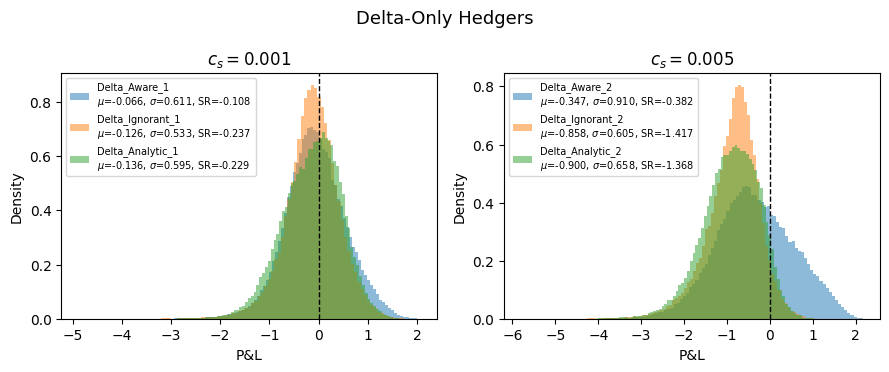

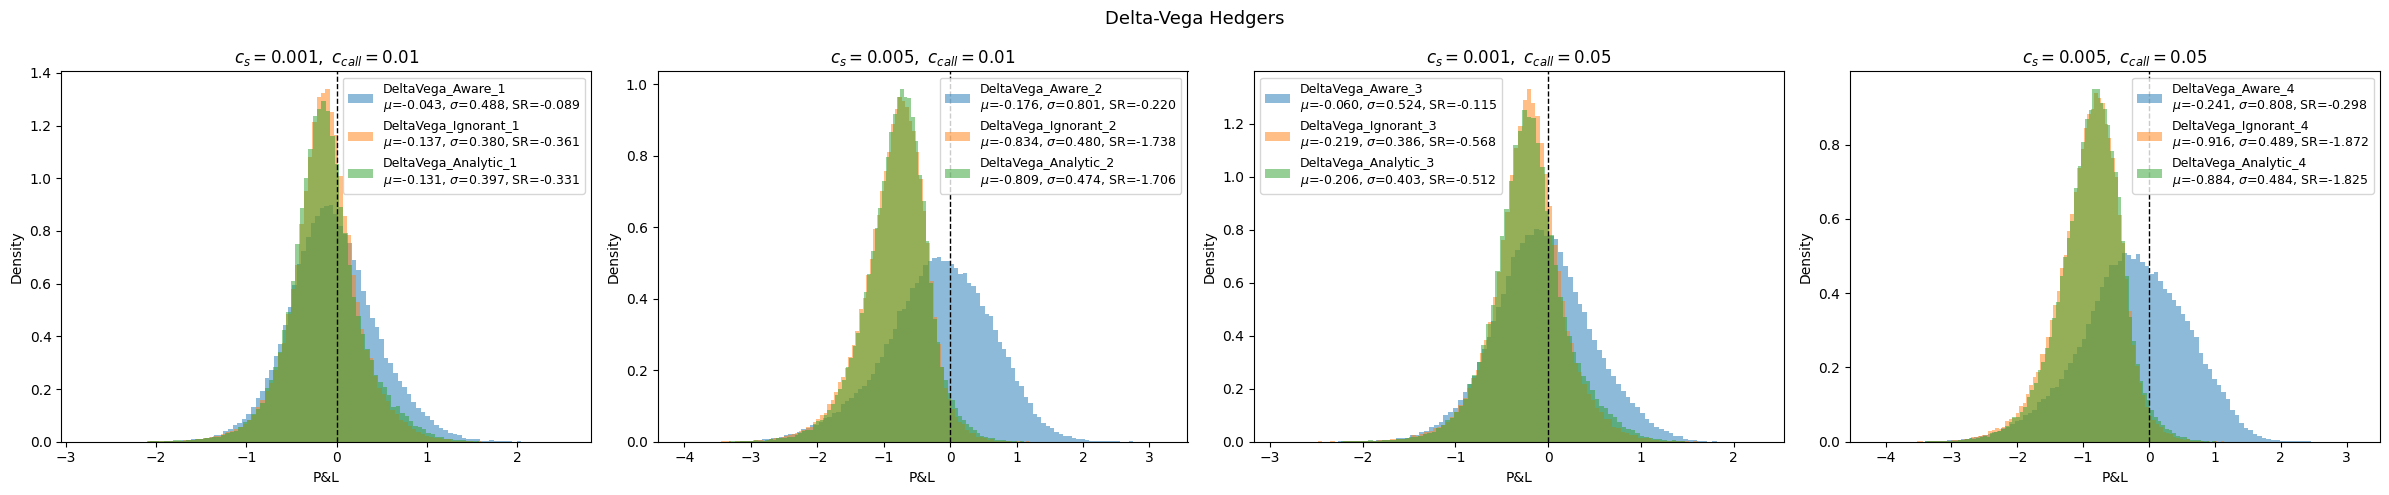

In [34]:
# Histograms — delta-only and delta-vega hedgers, with analytic benchmarks

def plot_generation(groups, suptitle, figsize=None, legend_fontsize=9, save_path=None):
    n_cols = len(groups)
    fig, axes = plt.subplots(1, n_cols, figsize=figsize or (6 * n_cols, 5))
    if n_cols == 1:
        axes = [axes]

    for col, (names, col_title) in enumerate(groups):
        ax = axes[col]
        for name in names:
            adj_pnl   = adj_pnls[name]
            mu, sigma = adj_pnl.mean(), adj_pnl.std()
            sharpe    = mu / sigma if sigma != 0 else float('nan')
            ax.hist(adj_pnl, bins=100, alpha=0.5, density=True,
                    label=f'{name}\n$\\mu$={mu:.3f}, $\\sigma$={sigma:.3f}, SR={sharpe:.3f}')
        ax.axvline(0, color='black', linestyle='--', lw=1)
        ax.set_title(col_title)
        ax.set_xlabel('P&L')
        ax.set_ylabel('Density')
        ax.legend(fontsize=legend_fontsize)

    plt.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


def pair_title(model):
    if isinstance(model, DeltaHedger):
        return f'$c_s={model.c_s_eval}$'
    return f'$c_s={model.c_s_eval},\\ c_{{call}}={model.c_call_eval}$'


# Split models_list into delta-only and delta-vega groups, each paired with its
# matching analytic Heston-Greek benchmark (same transaction-cost regime)
delta_groups     = []
deltavega_groups = []

for i in range(0, len(models_list), 2):
    ca = models_list[i]
    ci = models_list[i + 1]
    if isinstance(ca, DeltaHedger):
        idx   = len(delta_groups) + 1
        names = [ca.name, ci.name, f'Delta_Analytic_{idx}']
        delta_groups.append((names, pair_title(ca)))
    else:
        idx   = len(deltavega_groups) + 1
        names = [ca.name, ci.name, f'DeltaVega_Analytic_{idx}']
        deltavega_groups.append((names, pair_title(ca)))

# Figure 1: Delta-only hedgers
plot_generation(delta_groups, 'Delta-Only Hedgers', figsize=(9, 3.75), legend_fontsize=7,
                save_path=SAVE_PATH + 'delta_only_hedgers.png')

# Figure 2: Delta-Vega hedgers
plot_generation(deltavega_groups, 'Delta-Vega Hedgers',
                save_path=SAVE_PATH + 'deltavega_hedgers.png')

## Results: Hedge Ratio Trajectories

Aggregate risk statistics indicate whether a hedging strategy performs well, but they do not reveal how that performance is achieved. To examine the learned behavior more directly, we plot the hedge ratios $(\delta_S, \delta_{C_2})$ day by day along five held-out `plot` paths, together with the corresponding trajectories of the underlying stock price, instantaneous volatility, and option prices. This provides a qualitative sanity check that the network’s decisions are economically sensible—for example, that $\delta_S$ moves toward 0 or 1 as `C1` becomes deep out of or in the money near expiry, and that $\delta_{C_2}$ adjusts in response to changes in the latent volatility path. It also makes the effect of cost-aware training visually apparent: because they are optimized under an explicit transaction-cost penalty, the cost-aware models tend to produce noticeably smoother hedge-ratio trajectories, whereas their cost-ignorant counterparts rebalance more aggressively from day to day.


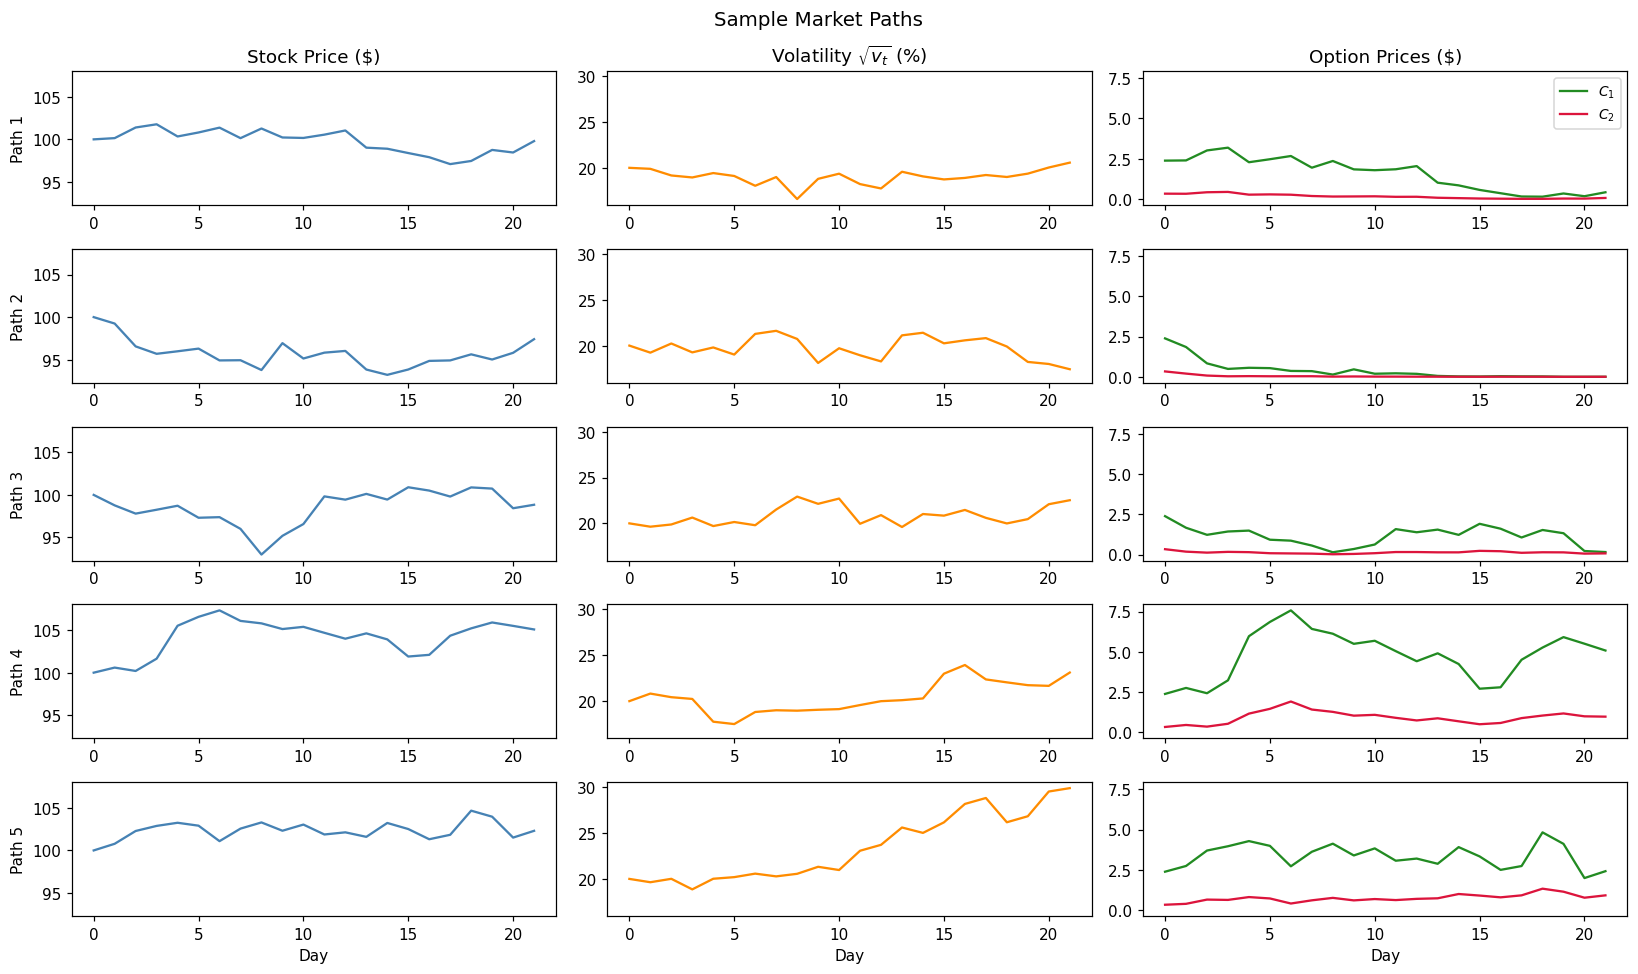
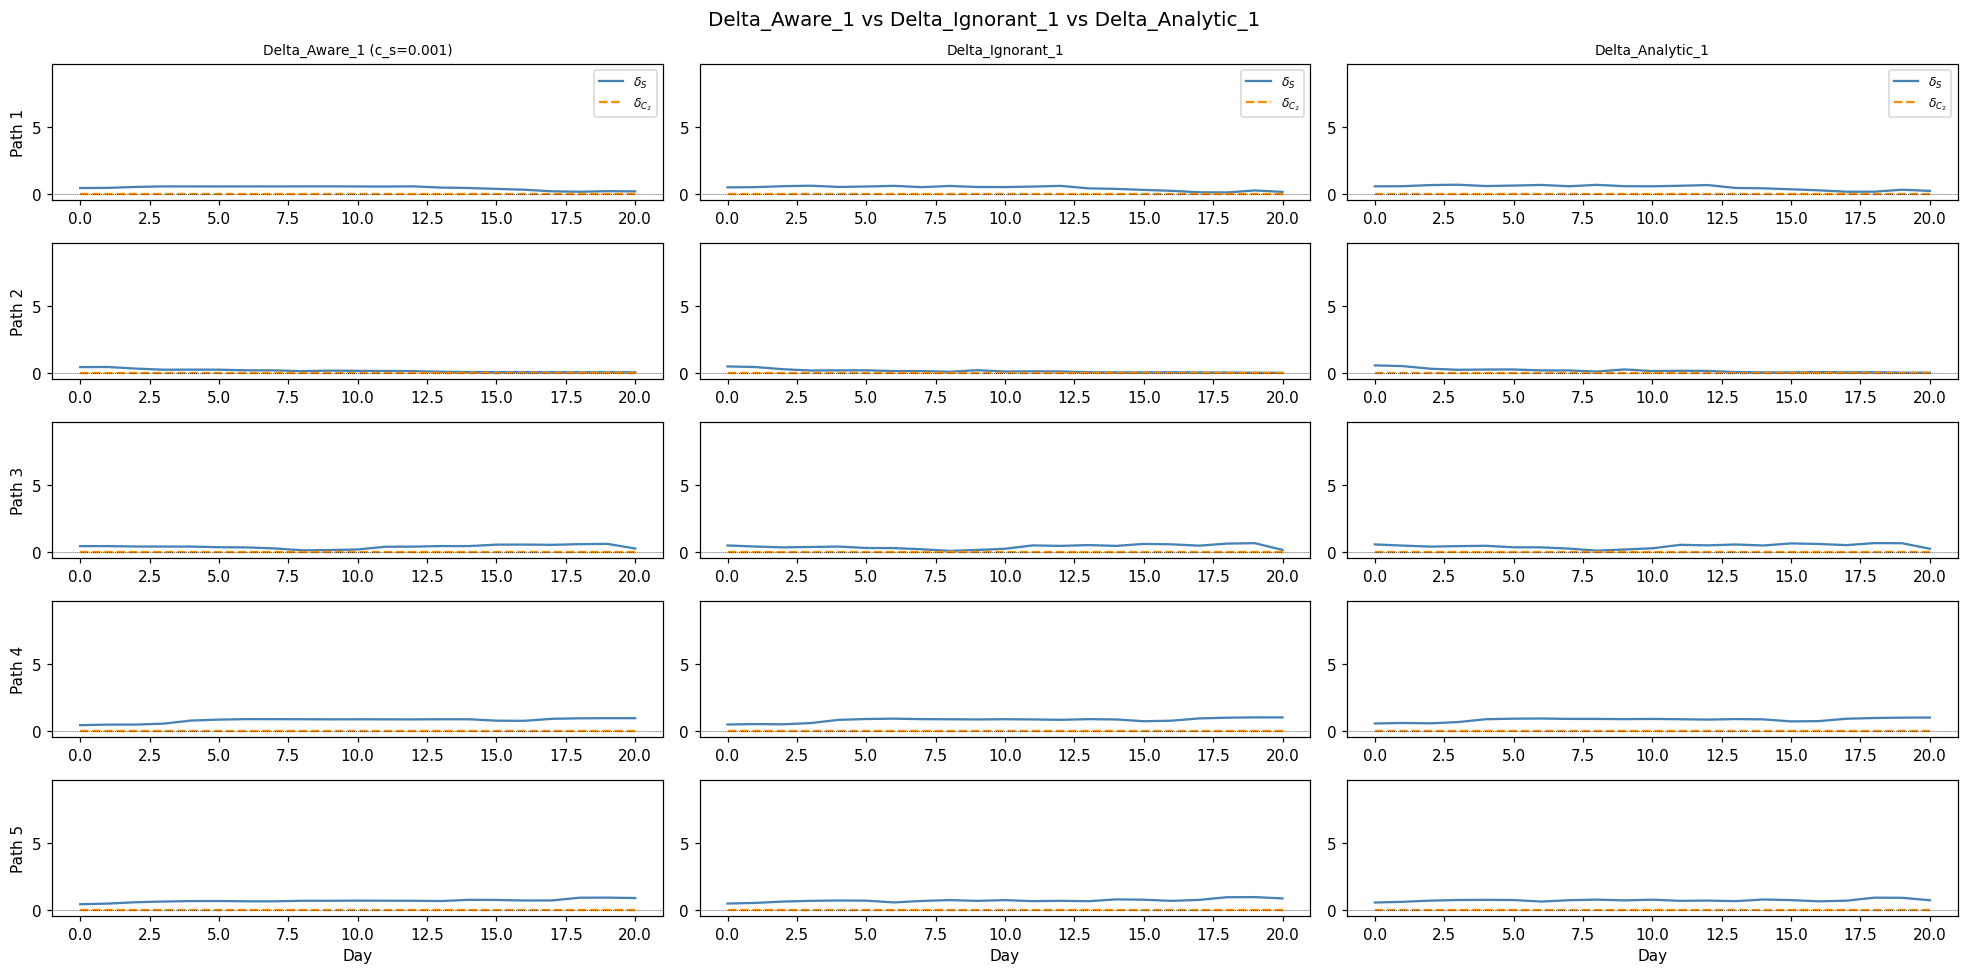
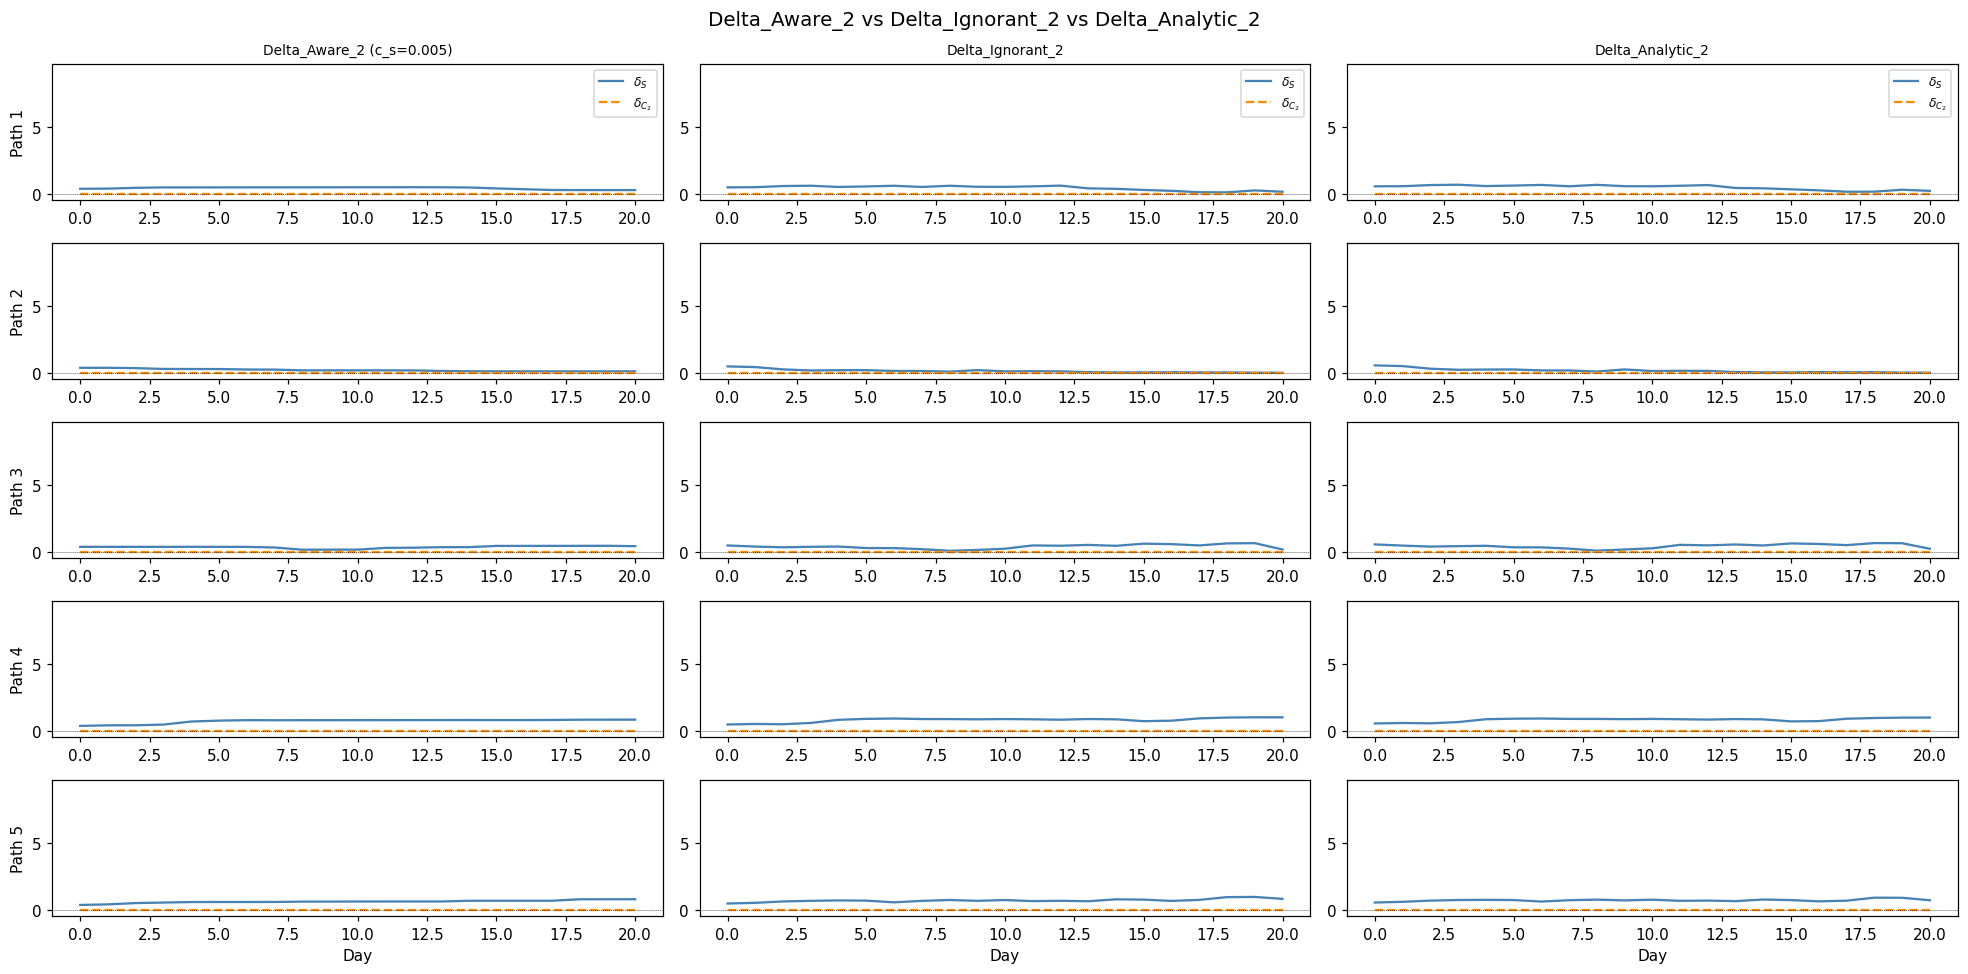
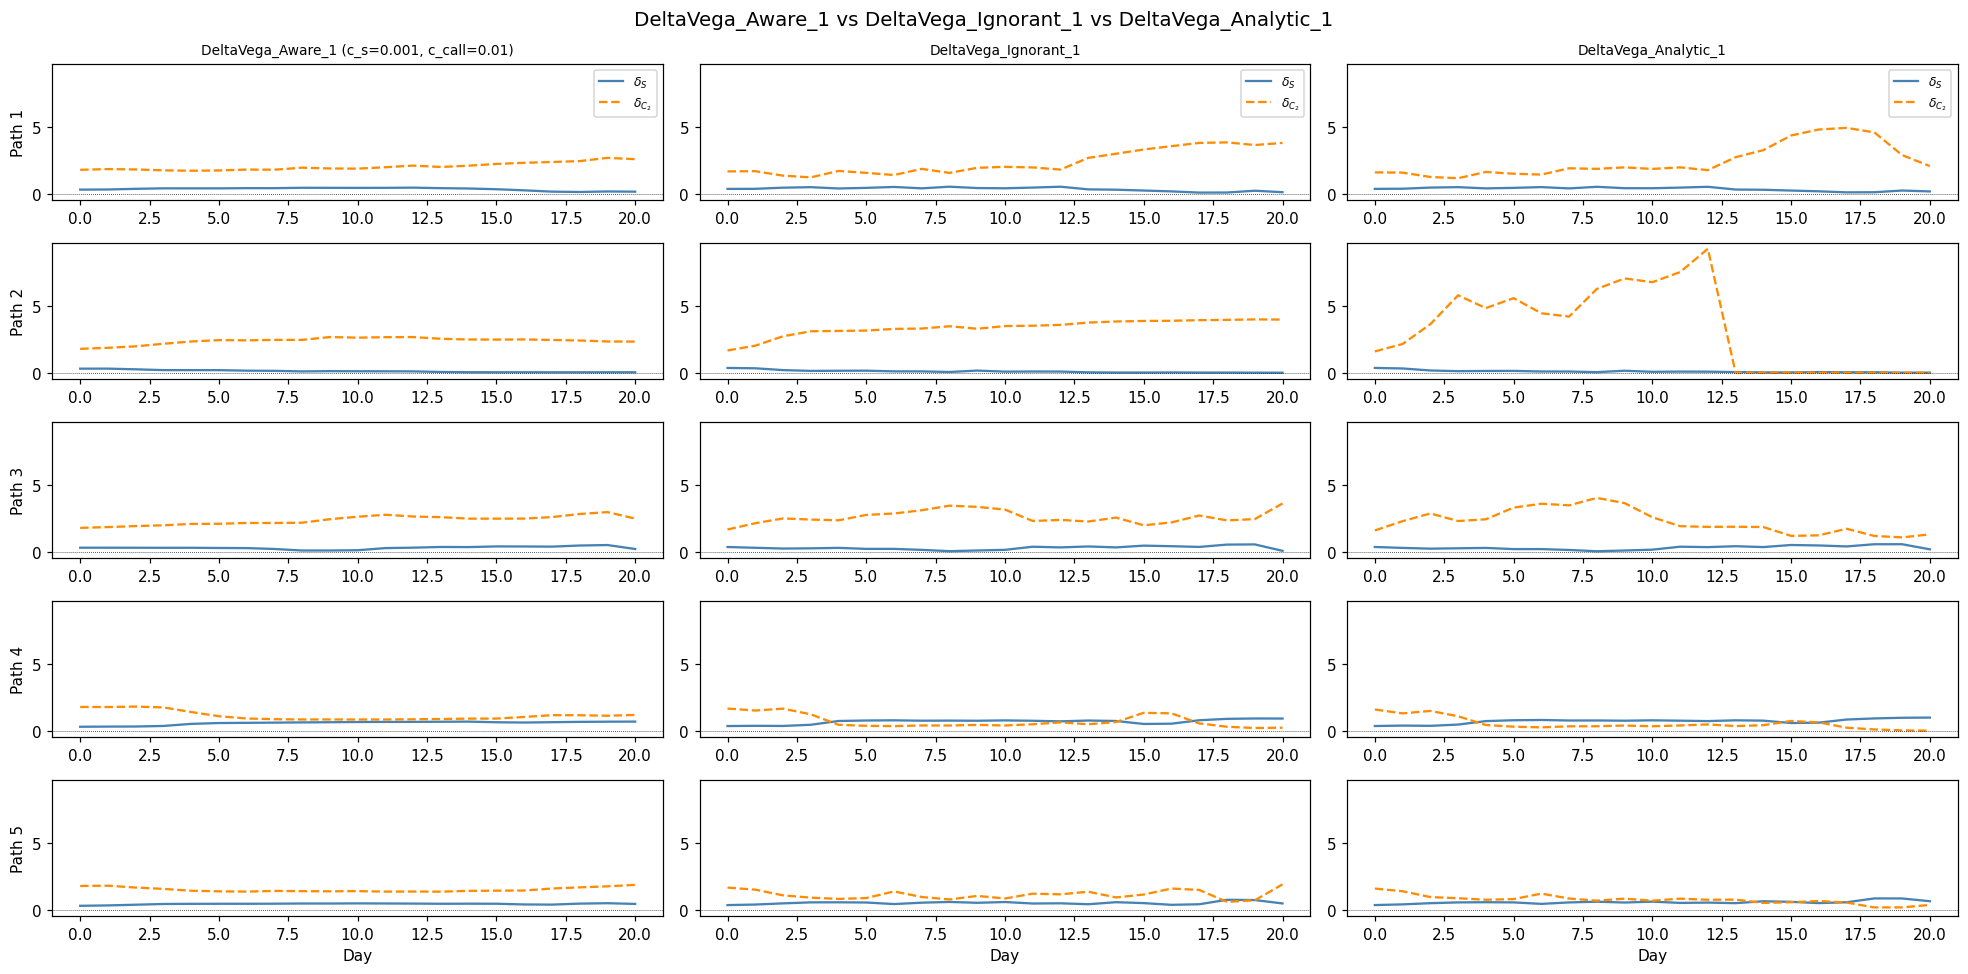
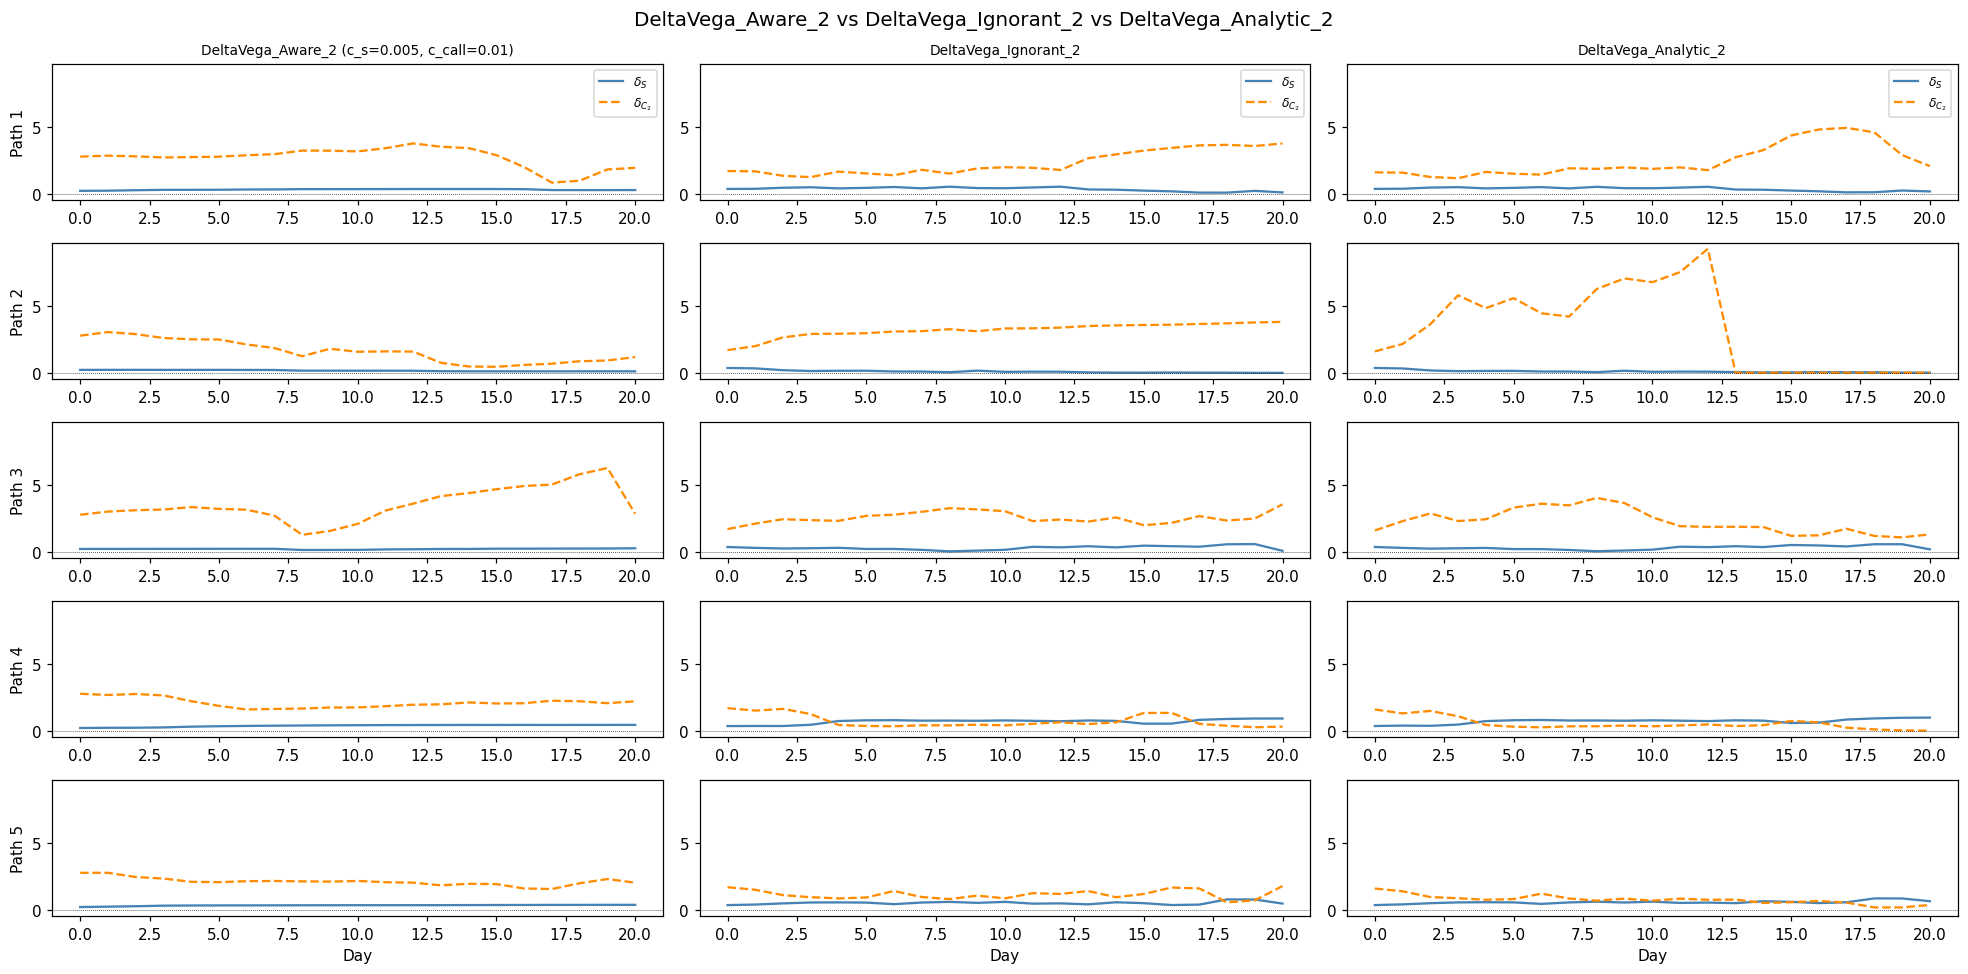
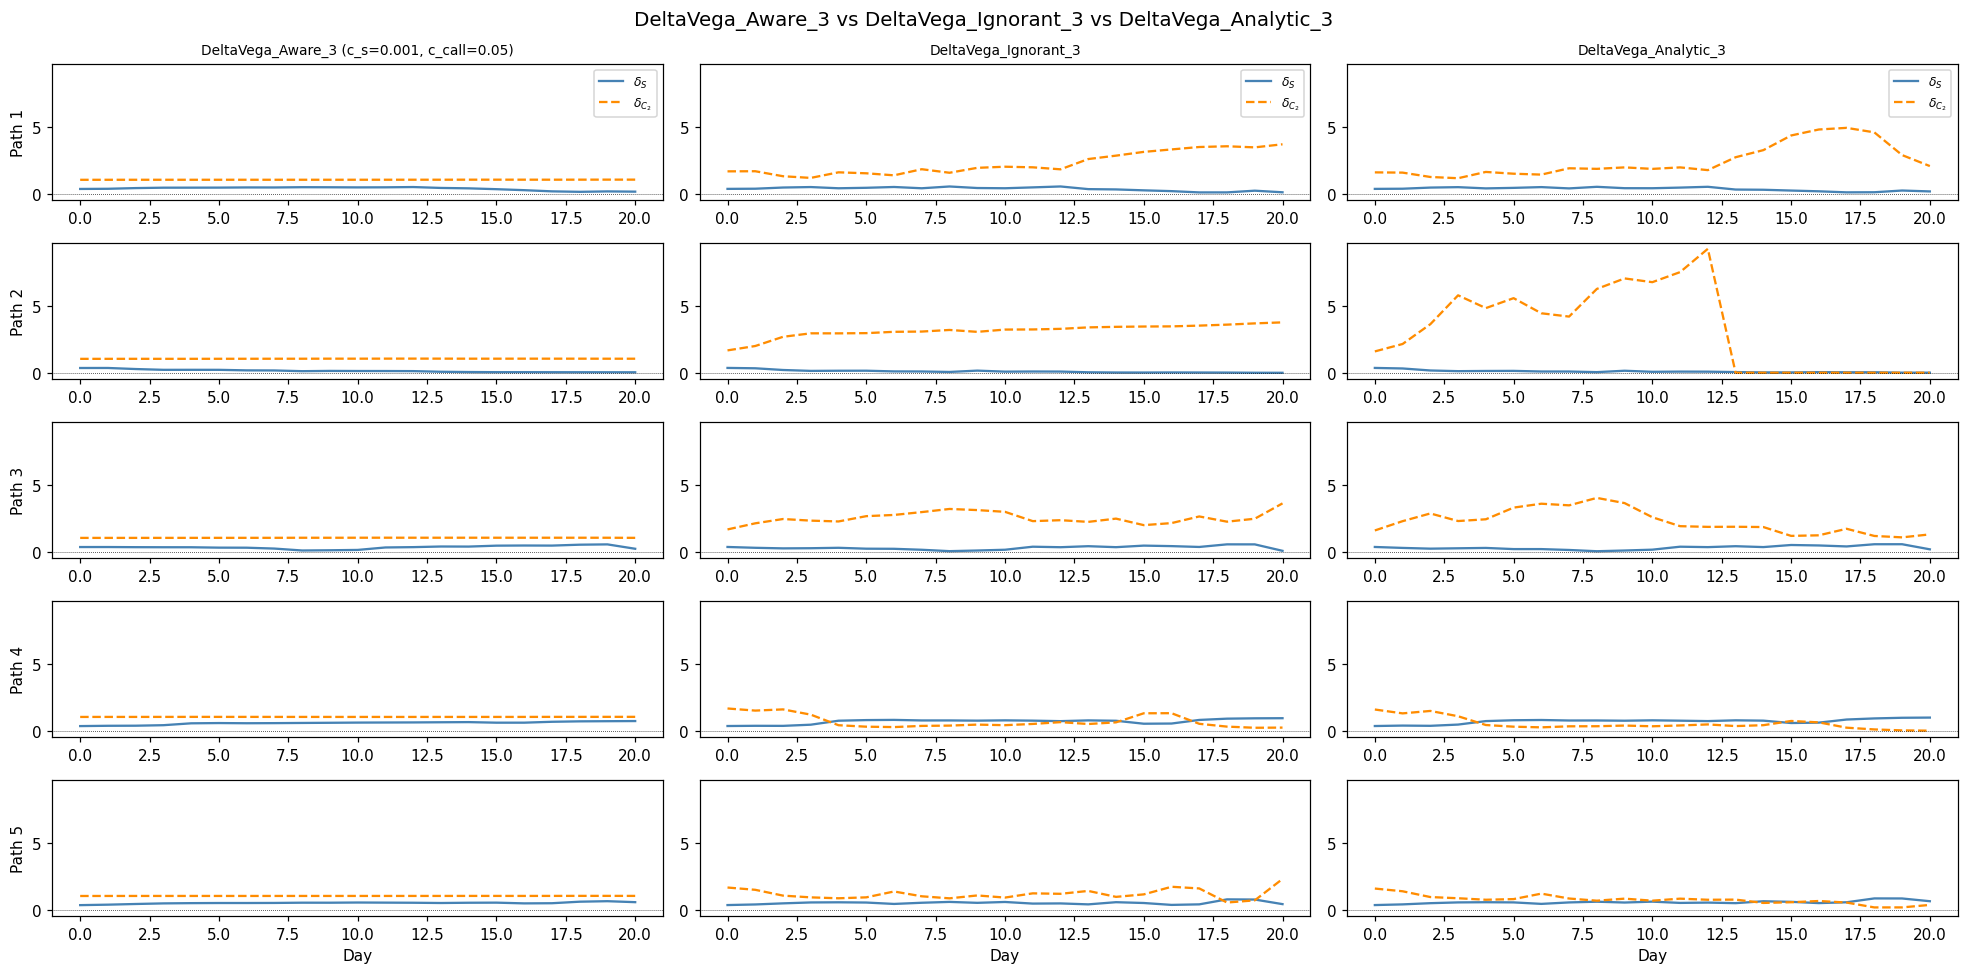
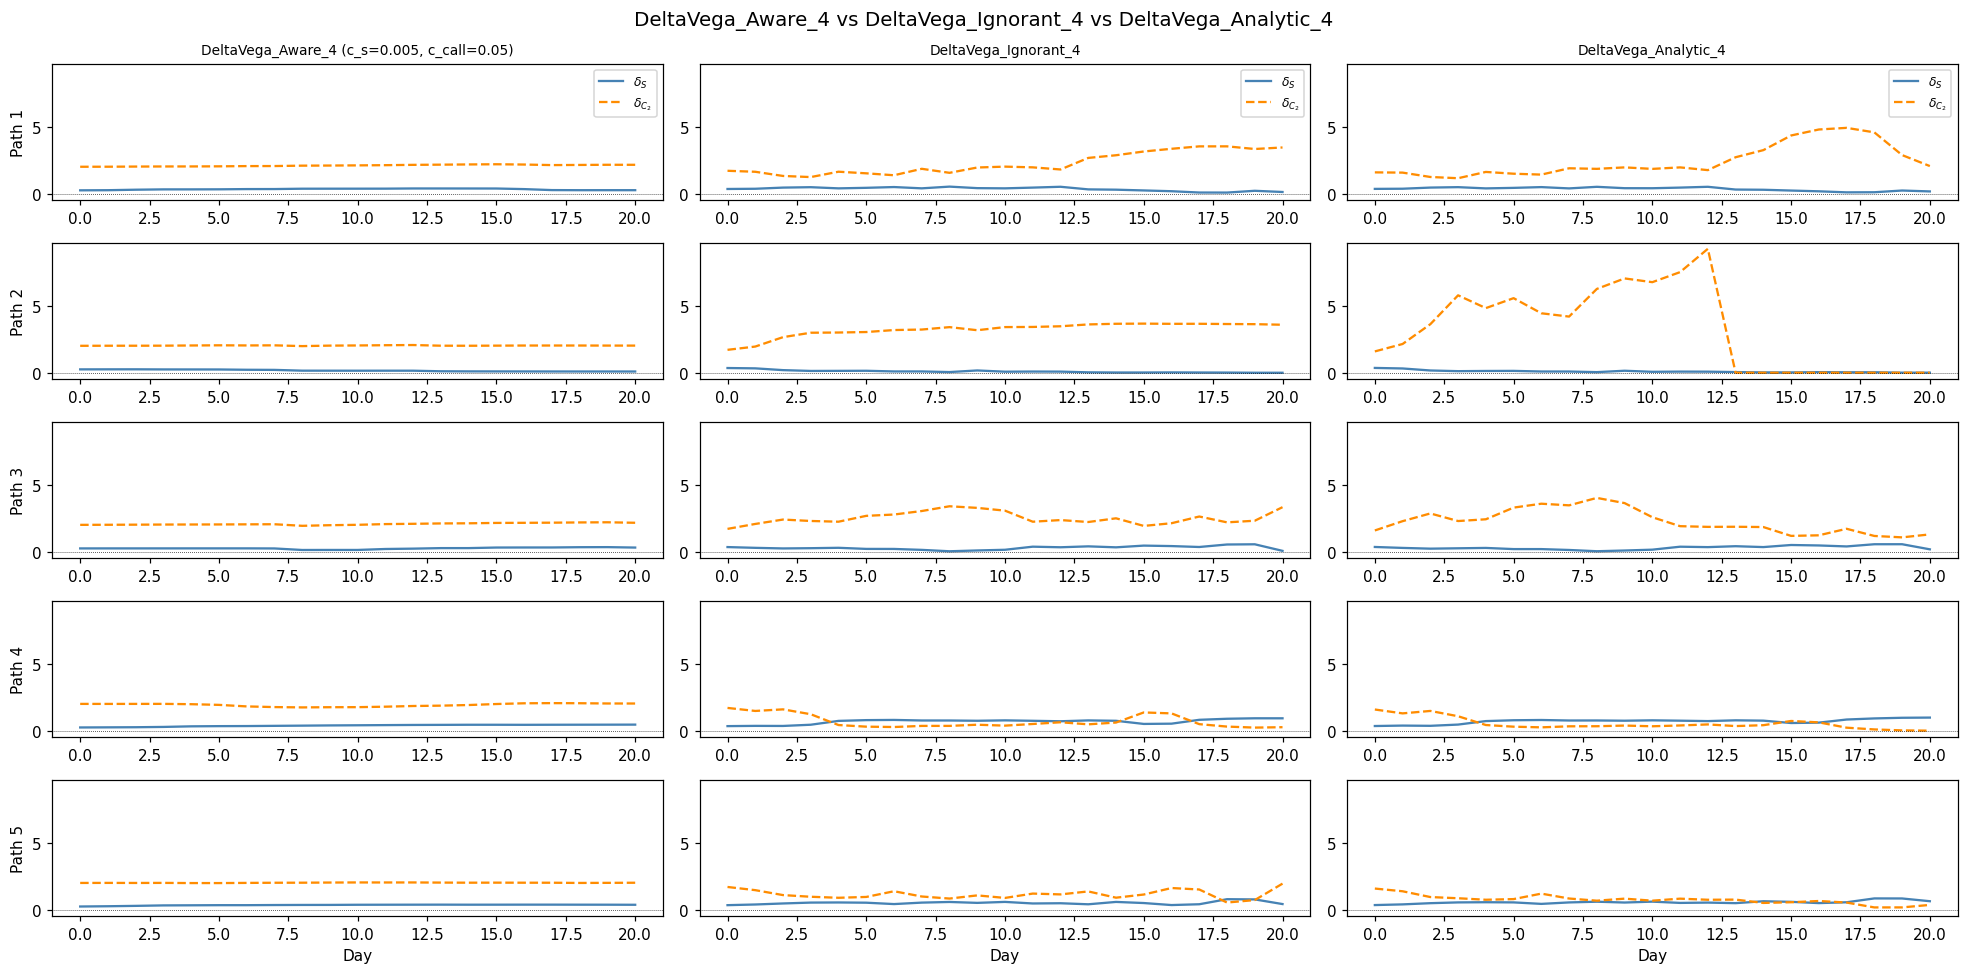

In [35]:
# Hedge ratio trajectories

import io
import base64
from IPython.display import HTML, display

days       = np.arange(N + 1)
days_hedge = np.arange(N)

# Compute hedge ratios for all models on the 5 plot paths
deltas_by_model = {}
for model in models_list:
    model.eval()
    with torch.no_grad():
        deltas_by_model[model.name] = model(S_plot, C1_plot, C2_plot).cpu().numpy()  # (5, N, 2)

# Analytic Heston-Greek hedge ratios on the same 5 plot paths (cost-independent,
# so one trajectory each covers every cost regime for its group)
analytic_delta_ratios_plot     = compute_analytic_delta_ratios(S_plot, V_plot).cpu().numpy()
analytic_deltavega_ratios_plot = compute_analytic_deltavega_ratios(S_plot, V_plot).cpu().numpy()

S_np  = S_plot.cpu().numpy()
V_np  = V_plot.cpu().numpy()
C1_np = C1_plot.cpu().numpy()
C2_np = C2_plot.cpu().numpy()

def padded(lo, hi, pad=0.05):
    margin = (hi - lo) * pad
    return lo - margin, hi + margin

vol_np     = np.sqrt(np.maximum(V_np, 0)) * 100
all_deltas = np.stack(list(deltas_by_model.values()) + [analytic_delta_ratios_plot, analytic_deltavega_ratios_plot])

ylim_S = padded(S_np.min(),       S_np.max())
ylim_V = padded(vol_np.min(),     vol_np.max())
ylim_C = padded(min(C1_np.min(), C2_np.min()), max(C1_np.max(), C2_np.max()))
ylim_d = padded(all_deltas.min(), all_deltas.max())

# Each figure is rendered to a PNG and collected here instead of being shown
# inline, so that they can be laid out side by side in a horizontally
# scrollable strip below — easier to compare across figures than scrolling
# down through them one at a time.
figure_imgs = []

def stash_figure(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight')
    plt.close(fig)
    encoded = base64.b64encode(buf.getvalue()).decode('ascii')
    figure_imgs.append(encoded)

# Figure 1: Market paths
fig, axes = plt.subplots(5, 3, figsize=(15, 9))

for i in range(5):
    axes[i, 0].plot(days, S_np[i], lw=1.5, color='steelblue')
    axes[i, 0].set_ylim(ylim_S)
    axes[i, 0].set_ylabel(f'Path {i+1}')
    if i == 0: axes[i, 0].set_title('Stock Price ($)')

    axes[i, 1].plot(days, vol_np[i], lw=1.5, color='darkorange')
    axes[i, 1].set_ylim(ylim_V)
    if i == 0: axes[i, 1].set_title(r'Volatility $\sqrt{v_t}$ (%)')

    axes[i, 2].plot(days, C1_np[i], lw=1.5, color='forestgreen', label='$C_1$')
    axes[i, 2].plot(days, C2_np[i], lw=1.5, color='crimson',     label='$C_2$')
    axes[i, 2].set_ylim(ylim_C)
    if i == 0:
        axes[i, 2].set_title('Option Prices ($)')
        axes[i, 2].legend(fontsize=9)

    if i == 4:
        for j in range(3):
            axes[i, j].set_xlabel('Day')

plt.suptitle('Sample Market Paths', fontsize=13)
plt.tight_layout()
stash_figure(fig)

# One figure per hedger pair: 5 rows × 3 cols (Aware, Ignorant, Analytic)
delta_idx, deltavega_idx = 0, 0
for i in range(0, len(models_list), 2):
    ca = models_list[i]
    ci = models_list[i + 1]

    if isinstance(ca, DeltaHedger):
        delta_idx     += 1
        analytic_name  = f'Delta_Analytic_{delta_idx}'
        analytic_ratio = analytic_delta_ratios_plot
    else:
        deltavega_idx += 1
        analytic_name  = f'DeltaVega_Analytic_{deltavega_idx}'
        analytic_ratio = analytic_deltavega_ratios_plot

    fig, axes = plt.subplots(5, 3, figsize=(18, 9))

    columns = [
        (deltas_by_model[ca.name], model_label(ca)),
        (deltas_by_model[ci.name], ci.name),
        (analytic_ratio,           analytic_name),
    ]

    for path in range(5):
        for col, (d, title) in enumerate(columns):
            ax = axes[path, col]
            ax.plot(days_hedge, d[path, :, 0], lw=1.5, color='steelblue',  label=r'$\delta_S$')
            ax.plot(days_hedge, d[path, :, 1], lw=1.5, color='darkorange', ls='--', label=r'$\delta_{C_2}$')
            ax.axhline(0, color='black', lw=0.5, ls=':')
            ax.set_ylim(ylim_d)

            if col == 0:
                ax.set_ylabel(f'Path {path+1}')
            if path == 0:
                ax.set_title(title, fontsize=9)
                ax.legend(fontsize=8, loc='upper right')
            if path == 4:
                ax.set_xlabel('Day')

    plt.suptitle(f'{ca.name} vs {ci.name} vs {analytic_name}', fontsize=13)
    plt.tight_layout()
    stash_figure(fig)

# Lay all figures out in one horizontally scrollable row
img_tags = ''.join(
    f'<img src="data:image/png;base64,{img}" style="height:520px; display:inline-block; margin-right:16px;">'
    for img in figure_imgs
)
display(HTML(
    f'<div style="overflow-x:auto; white-space:nowrap; border:1px solid #444; padding:8px;">{img_tags}</div>'
))

## Conclusion

- **Vega hedging cuts tail risk by ~25%, for learned and analytic hedgers alike.** At $c_s=0.001$, adding the `C2` hedge drops 5% CVaR from 1.39 → 1.05 for the cost-aware network, and 2.44 → 1.95 for the analytic Heston-Greek hedge at $c_s=0.005$. This is a property of the Heston dynamics, not just something the networks learned.

- **Cost-awareness pays off most when frictions are large.** At $c_s=0.001$ the three approaches (aware, ignorant, analytic) perform similarly. At $c_s=0.005$, cost-aware training wins decisively on mean P&L (−0.35 vs. −0.86 for delta-only) *and* on tail risk (CVaR5% 2.24 vs. 2.39) — being cost-blind, whether by training choice or by construction (the analytic hedge), is expensive once turnover isn't free.

- **The classical Greek hedge is not a gold standard.** For delta-only hedging it's the worst of the three strategies on every metric, at every cost level. For delta-vega, it's competitive with the cost-ignorant network but numerically fragile: its `C2` hedge ratio spikes to several times notional as `C2`'s own vega collapses near maturity — an instability the learned hedgers avoid entirely.

**Bottom line:** deep hedging beats both a naive cost-blind strategy and the textbook closed-form hedge, and the gap widens as transaction costs rise.